# ACP-CD vs SelfCheckGPT — Multi-Dataset Benchmark (Fixed)
## TruthfulQA · HotpotQA · WikiBio

### Fixes applied vs original notebook
1. **Stop sequences** added to both GGUF and HF generation — prevents prompt continuation bug
2. **Response cleaning** added — safety-net truncation at `Question:` / `Q:` markers
3. **max_new_tokens** reduced from 200 → 80 tokens (1-2 sentences ≈ 50-70 tokens)
4. **Greedy decoding** fixed: `do_sample=False` for HF, `temperature=0.0` for GGUF
5. **TruthfulQA labelling** fixed: uses dataset's `correct_answers`/`incorrect_answers`
6. **HotpotQA labelling** fixed: NLI threshold raised to 0.6, improved exact-match
7. **`_sent_tokenize_safe`** unifies sentence splitting (spacy) across the whole pipeline
8. **`subprocess` import** moved to top-level imports cell


## Cell 1 — Install

In [2]:
import subprocess
pkgs = ["networkx", "scikit-learn", "datasets", "selfcheckgpt",
        "spacy", "bert-score"]
subprocess.run(["pip", "install", "-q"] + pkgs, check=False)
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm", "-q"], check=False)
print("Packages installed ✓")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Packages installed ✓


## Cell 2 — Imports & GPU setup

In [3]:
import re, json, itertools, warnings, os, ast, pickle, subprocess
from dataclasses import dataclass, field
from enum import Enum
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn as nn
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoModelForCausalLM, pipeline)

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS = torch.cuda.device_count()
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}  |  GPUs: {N_GPUS}")
for i in range(N_GPUS):
    print(f"  GPU {i}  : {torch.cuda.get_device_name(i)}")


PyTorch  : 2.10.0+cu128
Device   : cuda  |  GPUs: 2
  GPU 0  : Tesla T4
  GPU 1  : Tesla T4


## Cell 3 — Data structures

In [4]:
class ClaimType(Enum):
    ENTITY       = "entity"
    RELATIONAL   = "relational"
    TEMPORAL     = "temporal"
    QUANTITATIVE = "quantitative"
    LOCATIONAL   = "locational"
    EPISTEMIC = "epistemic"
    
@dataclass
class AtomicClaim:
    text: str
    claim_type: ClaimType
    source_sentence_idx: int

@dataclass
class ConsistencyResult:
    claim: AtomicClaim
    hallucination_score: float
    samples_used: int
    variance_history: list = field(default_factory=list)

@dataclass
class SentenceResult:
    sentence: str
    sentence_idx: int
    claims: list
    claim_results: list
    sentence_score: float
    claim_type_breakdown: dict = field(default_factory=dict)

@dataclass
class PassageResult:
    passage: str
    sentence_results: list
    passage_score: float
    graph_divergence_score: float
    final_score: float
    is_total_hallucination: bool = False

print("Data structures ✓")


Data structures ✓


## Cell 4 — Claim Decomposer

In [5]:

# =============================================================================
# CELL 8 — ClaimDecomposer
# Replace the ENTIRE cell content with this.
# =============================================================================
 
class ClaimDecomposer:
    """
    Converts a sentence into a list of AtomicClaims.
 
    v3 changes (epistemic/TruthfulQA fixes):
    - EPISTEMIC_KEYWORDS: tight set of hedge/belief surface forms.
      _classify() checks these FIRST so myth sentences get the EPISTEMIC type,
      which triggers inverted NLI scoring in ACPCD._sc().
    - _NEGATION_CORRECTION: splits "X is not true — however Y" into two claims:
      [myth half → EPISTEMIC] + [correction half → normal type].
      The 0.6*max + 0.4*mean aggregation then lets the myth claim drive the
      sentence score when it scores high via inverted NLI.
    - All v2 rules preserved unchanged: MIN_TOKENS=6, contrastive-keep,
      semicolon-split.
    """
 
    TEMPORAL_KEYWORDS = {
        "born","died","founded","established","created","invented","published",
        "released","married","graduated","appointed","elected","retired",
        "year","century","decade","january","february","march","april","may",
        "june","july","august","september","october","november","december",
    }
    QUANTITATIVE_KEYWORDS = {
        "million","billion","thousand","hundred","percent","%",
        "km","miles","kg","pounds","meters","feet","dollars","euros",
    }
    LOCATIONAL_KEYWORDS = {
        "in","at","from","near","located","based","city","country",
        "state","province","region","north","south","east","west",
    }
 
    # Tight set — only surface forms that appear almost exclusively in
    # myth/belief contexts. Deliberately excludes 'according to', 'believed',
    # 'is considered', 'actually' (all cause false positives on correct TQA entries).
    EPISTEMIC_KEYWORDS = {
        # Single-word tokens
        "contrary","myth","misconception","folklore","supposedly","allegedly",
        "rumored","traditionally","popularly","widely",
        # Multi-word phrases (checked via substring match)
        "often claimed","people think","most people","everyone knows",
        "generally believed","long believed","widely believed",
        "commonly believed","often believed","popular belief",
        "common misconception","old wives","urban legend",
        "not scientifically","no scientific evidence",
        "it is said to","are said to","widely held","commonly held",
        "popularly believed",
    }
 
    # Contrastive conjunctions → keep whole sentence as one claim (v2, unchanged)
    _CONTRASTIVE = re.compile(r",\s+(?:while|whereas|although|though)\s+", re.I)
 
    # Semicolons → independent-clause boundary (v2, unchanged)
    _SEMICOLON = re.compile(r";\s+")
 
    # Negation-correction split: "myth half [boundary] correction half"
    # Fires on explicit correction markers only. Requires MIN_TOKENS on both
    # sides before splitting so fragment claims are never produced.
    _NEGATION_CORRECTION = re.compile(
        r"\b(?:not\s+true|in\s+fact|contrary\s+to|however[,\s]"
        r"|despite\s+(?:popular|common)|rather[,\s]|instead[,\s])\b",
        re.I,
    )
 
    MIN_TOKENS = 6
 
    def __init__(self):
        pass
 
    def decompose(self, sentence: str, idx: int) -> list:
        text = sentence.strip()
 
        # Too short to be meaningful
        if len(text.split()) < self.MIN_TOKENS:
            return []
 
        # Rule 1 (v2): contrastive conjunction → single claim
        if self._CONTRASTIVE.search(text):
            return [AtomicClaim(text, self._classify(text), idx)]
 
        # Rule 2 (NEW): negation-correction split
        # e.g. "Veins appear blue [however,] veins are not actually blue"
        # → [EPISTEMIC: myth half] + [normal: correction half]
        m = self._NEGATION_CORRECTION.search(text)
        if m:
            before = text[:m.start()].strip().rstrip(",")
            after  = text[m.start():].strip()
            if (len(before.split()) >= self.MIN_TOKENS
                    and len(after.split()) >= self.MIN_TOKENS):
                return [
                    AtomicClaim(before, ClaimType.EPISTEMIC, idx),  # myth half
                    AtomicClaim(after,  self._classify(after), idx), # correction
                ]
 
        # Rule 3 (v2): semicolon → two independent claims
        semi_parts = self._SEMICOLON.split(text)
        if len(semi_parts) == 2:
            a, b = semi_parts[0].strip(), semi_parts[1].strip()
            if (len(a.split()) >= self.MIN_TOKENS
                    and len(b.split()) >= self.MIN_TOKENS):
                return [
                    AtomicClaim(a, self._classify(a), idx),
                    AtomicClaim(b, self._classify(b), idx),
                ]
 
        # Default: whole sentence = single atomic claim
        return [AtomicClaim(text, self._classify(text), idx)]
 
    def _classify(self, c: str) -> ClaimType:
        toks  = set(c.lower().split())
        c_low = c.lower()
 
        # EPISTEMIC checked FIRST — single-word token check + multi-word substring
        if toks & self.EPISTEMIC_KEYWORDS:
            return ClaimType.EPISTEMIC
        if any(kw in c_low for kw in self.EPISTEMIC_KEYWORDS if " " in kw):
            return ClaimType.EPISTEMIC
 
        # Remaining types unchanged from v2
        if re.search(r"\b(1[0-9]{3}|20[0-2][0-9])\b", c): return ClaimType.TEMPORAL
        if toks & self.TEMPORAL_KEYWORDS:                   return ClaimType.TEMPORAL
        if re.search(r"\b\d+[\.,]?\d*\b", c):             return ClaimType.QUANTITATIVE
        if toks & self.QUANTITATIVE_KEYWORDS:              return ClaimType.QUANTITATIVE
        if toks & self.LOCATIONAL_KEYWORDS and re.search(r"\b[A-Z][a-z]+\b", c):
            return ClaimType.LOCATIONAL
        if re.search(r"\b(?:is|was|are|were)\s+(?:a|an|the)\b", c):
            return ClaimType.ENTITY
        return ClaimType.RELATIONAL
 
print("ClaimDecomposer ✓")

ClaimDecomposer ✓


## Cell 5 — NLI Checker (DeBERTa-v3-large, DataParallel)

In [6]:
class NLIChecker:
    MODEL = "cross-encoder/nli-deberta-v3-large"

    def __init__(self):
        print(f"[NLI] Loading {self.MODEL} ...")
        self.tok = AutoTokenizer.from_pretrained(self.MODEL)
        m = AutoModelForSequenceClassification.from_pretrained(self.MODEL)
        if N_GPUS > 1:
            print(f"[NLI] DataParallel on {N_GPUS} GPUs")
            m = nn.DataParallel(m)
        self.model = m.to(DEVICE).eval()
        self.ci, self.ei = 0, 1
        print("[NLI] Ready ✓")

    def _logits(self, inputs):
        m = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        return m(**inputs).logits

    @torch.no_grad()
    def score(self, claim: str, sample: str) -> float:
        inp = self.tok(sample, claim, truncation=True, max_length=512,
                       return_tensors="pt").to(DEVICE)
        lg = self._logits(inp)[0]
        ze, zc = lg[self.ei].item(), lg[self.ci].item()
        return float(np.exp(zc) / (np.exp(ze) + np.exp(zc)))

    @torch.no_grad()
    def batch_score(self, claim: str, samples: list, bs: int = 16) -> list:
        out = []
        for i in range(0, len(samples), bs):
            batch = samples[i:i+bs]
            inp = self.tok(batch, [claim]*len(batch), truncation=True,
                           max_length=512, padding=True,
                           return_tensors="pt").to(DEVICE)
            lg = self._logits(inp)
            ze, zc = lg[:, self.ei], lg[:, self.ci]
            out.extend((torch.exp(zc)/(torch.exp(ze)+torch.exp(zc))).cpu().tolist())
        return out


## Cell 6 — Adaptive Sampler & Claim Graph Builder

In [7]:
class AdaptiveSampler:
    def __init__(self, n_init=3, n_max=20, n_min_unc=8, lv=0.02, hv=0.08):
        self.n_init, self.n_max = n_init, n_max
        self.n_min_unc, self.lv, self.hv = n_min_unc, lv, hv

    def should_stop(self, scores):
        n = len(scores)
        if n < self.n_init:  return False
        if n >= self.n_max:  return True
        v = float(np.var(scores))
        if v < self.lv:                          return True
        if v >= self.hv and n >= self.n_min_unc: return True
        return False

    def agg(self, scores): return float(np.mean(scores))


class ClaimGraphBuilder:
    ET, CT = 0.70, 0.60

    def __init__(self, nli):
        self.nli = nli

    def build(self, claims):
        G = nx.DiGraph()
        for i, c in enumerate(claims):
            G.add_node(i, text=c.text, ct=c.claim_type.value)
        for i, j in itertools.combinations(range(len(claims)), 2):
            pcij = self.nli.score(claims[j].text, claims[i].text)
            pcji = self.nli.score(claims[i].text, claims[j].text)
            if 1-pcij > self.ET:  G.add_edge(i, j, r="entails",    w=1-pcij)
            elif pcij > self.CT:  G.add_edge(i, j, r="contradicts", w=pcij)
            if 1-pcji > self.ET:  G.add_edge(j, i, r="entails",    w=1-pcji)
            elif pcji > self.CT:  G.add_edge(j, i, r="contradicts", w=pcji)
        return G

    @staticmethod
    def sig(G):
        n = G.number_of_nodes()
        if n == 0: return np.zeros(8)
        E  = list(G.edges(data=True))
        ne = sum(1 for _,_,d in E if d.get("r") == "entails")
        nc = sum(1 for _,_,d in E if d.get("r") == "contradicts")
        nt = max(len(E), 1)
        try:    cl = nx.average_clustering(G.to_undirected())
        except: cl = 0.0
        nw = nx.number_weakly_connected_components(G) if n > 1 else 1
        return np.array([n, ne, nc, nx.density(G), cl, nw, ne/nt, nc/nt], dtype=float)

    def divergence(self, rg, sgs):
        if not sgs: return 0.0
        rs = self.sig(rg)
        return float(min(np.mean([np.linalg.norm(rs - self.sig(sg)) for sg in sgs]) / 10, 1.0))

print("AdaptiveSampler + ClaimGraphBuilder ✓")


AdaptiveSampler + ClaimGraphBuilder ✓


## Cell 7 — ACP-CD Detector

**Fix 7:** `_sent_tokenize_safe` uses the global spacy-based `sent_tokenize` everywhere,
so sentence splitting is consistent. `score()` also accepts pre-split sentences from the
entry dict to avoid redundant re-splitting.


In [8]:
class ACPCD:
    GW, CW = 0.30, 0.70
    PRIOR = {
        ClaimType.TEMPORAL:     1.15,
        ClaimType.QUANTITATIVE: 1.10,
        ClaimType.RELATIONAL:   1.00,
        ClaimType.LOCATIONAL:   0.95,
        ClaimType.ENTITY:       0.90,
    }

    def __init__(self, nli, n_init=3, n_max=20, use_graph=True):
        self.dec  = ClaimDecomposer()
        self.nli  = nli
        self.samp = AdaptiveSampler(n_init=n_init, n_max=n_max)
        self.gb   = ClaimGraphBuilder(nli) if use_graph else None
        self.ug   = use_graph

    def score(self, response: str, samples: list,
              pre_split_sents: list = None) -> PassageResult:
        # FIX 7: use pre-split sentences when available
        sents = pre_split_sents if pre_split_sents else _sent_tokenize_safe(response)
        srs = []
        for idx, s in enumerate(sents):
            claims = self.dec.decompose(s, idx)
            crs    = [self._sc(c, samples) for c in claims]
            ss     = self._agg(crs)
            bd = {}
            for ct in ClaimType:
                rel = [r for r in crs if r.claim.claim_type == ct]
                if rel: bd[ct.value] = float(np.mean([r.hallucination_score for r in rel]))
            srs.append(SentenceResult(s, idx, claims, crs, ss, bd))
        cs = float(np.mean([sr.sentence_score for sr in srs])) if srs else 0.0
        gs = 0.0
        if self.ug and self.gb and samples:
            gs = self._gdiv(response, samples, srs)
        final = (self.CW * cs + self.GW * gs) if self.ug else cs
        return PassageResult(
            passage=response, sentence_results=srs,
            passage_score=cs, graph_divergence_score=gs,
            final_score=float(np.clip(final, 0, 1)),
            is_total_hallucination=(gs > 0.75 and cs > 0.70),
        )

# REPLACE WITH this (keep the 4-space indent — it's inside the ACPCD class):
    def _sc(self, claim, samples):
        scores, vh = [], []
 
        # EPISTEMIC claims need inverted NLI scoring AND a minimum sample count.
        #
        # Why inverted:
        #   NLIChecker.score() returns P(contradiction).
        #   For factual claims: hallucinated → samples disagree → HIGH contradiction
        #     → HIGH score → correctly flagged.
        #   For myth claims: model consistently repeats the myth across samples
        #     → LOW contradiction (samples AGREE) → LOW score → not flagged (WRONG).
        #   Fix: for EPISTEMIC, use (1 - p) so that sample agreement = HIGH score.
        #
        # Why min 8 samples:
        #   AdaptiveSampler stops at n_init=3 on low-variance streams.
        #   Myth responses are low-variance (always the same wrong answer),
        #   so we force at least 8 samples to give the inverted signal enough mass.
        is_epistemic = (claim.claim_type == ClaimType.EPISTEMIC)
        min_samples  = 8 if is_epistemic else 0
 
        for samp in samples:
            p = self.nli.score(claim.text, samp)
            # Invert p for epistemic claims before storing
            scores.append(1.0 - p if is_epistemic else p)
            vh.append(float(np.var(scores)) if len(scores) > 1 else 0.0)
            if len(scores) >= min_samples and self.samp.should_stop(scores):
                break
 
        prior = self.PRIOR.get(claim.claim_type, 1.0)
        # For EPISTEMIC, apply a 0.80 dampening factor so inverted scores
        # don't saturate at 1.0 on every myth.  Factual claim scoring is
        # unchanged (prior * raw_score as before).
        scale = 0.80 if is_epistemic else 1.0
        w = float(np.clip(self.samp.agg(scores) * prior * scale, 0, 1))
        return ConsistencyResult(claim, w, len(scores), vh)

    def _agg(self, crs):
        if not crs: return 0.0
        s = [r.hallucination_score for r in crs]
        return s[0] if len(s) == 1 else float(0.6 * max(s) + 0.4 * np.mean(s))

    def _gdiv(self, resp, samples, srs):
        ac = [c for sr in srs for c in sr.claims]
        if len(ac) < 2: return 0.0
        rg = self.gb.build(ac)
        sgs = []
        for st in samples[:5]:
            sc = [c for i, s in enumerate(_sent_tokenize_safe(st))
                  for c in self.dec.decompose(s, i)]
            if len(sc) >= 2: sgs.append(self.gb.build(sc))
        return self.gb.divergence(rg, sgs)


def _sent_tokenize_safe(text: str) -> list:
    """Spacy-based sentence splitting with regex fallback."""
    try:
        sents = sent_tokenize(text)
    except NameError:
        sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text.strip())
                 if len(s.strip()) > 10]
    return [s for s in sents if len(s.strip()) > 10] or [text]

print("ACPCD ✓")


ACPCD ✓


## Cell 8 — SelfCheckGPT Baseline (BERTScore)

In [9]:
try:
    from selfcheckgpt.modeling_selfcheck import SelfCheckBERTScore
    SELFCHECK_AVAILABLE = True
    print("selfcheckgpt library loaded ✓")
except ImportError:
    SELFCHECK_AVAILABLE = False
    print("selfcheckgpt not found — baseline will be skipped")


class SelfCheckWrapper:
    def __init__(self, device=DEVICE):
        self.name = "bertscore"
        if not SELFCHECK_AVAILABLE:
            self.impl = None
            return
        self.impl = SelfCheckBERTScore(rescale_with_baseline=True)

    def score(self, sentences: list, samples: list) -> list:
        if self.impl is None:
            return [0.5] * len(sentences)
        try:
            scores = self.impl.predict(sentences=sentences, sampled_passages=samples)
            return [float(s) for s in scores]
        except Exception as e:
            print("SelfCheck-BERTScore error: " + str(e))
            return [0.5] * len(sentences)

    def passage_score(self, sentences, samples):
        return float(np.mean(self.score(sentences, samples)))


print("Loading SelfCheckGPT-BERTScore...")
SC_VARIANTS = {}
try:
    SC_VARIANTS["bertscore"] = SelfCheckWrapper()
    print("  SelfCheck-BERTScore ✓")
except Exception as e:
    print("  SelfCheck-BERTScore failed: " + str(e))


selfcheckgpt library loaded ✓
Loading SelfCheckGPT-BERTScore...
SelfCheck-BERTScore initialized
  SelfCheck-BERTScore ✓


## Cell 9 — Download Mistral GGUF

In [10]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="bartowski/Mistral-7B-Instruct-v0.3-GGUF",
    filename="Mistral-7B-Instruct-v0.3-Q4_K_M.gguf",
    local_dir="/kaggle/working/"
)
print(model_path)


Mistral-7B-Instruct-v0.3-Q4_K_M.gguf:   0%|          | 0.00/4.37G [00:00<?, ?B/s]

/kaggle/working/Mistral-7B-Instruct-v0.3-Q4_K_M.gguf


## Cell 10 — Local LLM for generation

### Fixes applied
- **Fix 1 — stop sequences:** Both GGUF and HF paths now pass explicit stop sequences.
  The model stops immediately after the answer and never continues with fake Q&A.
- **Fix 2 — greedy decoding:** `do_sample=False` for HF; `temperature=0.0` for GGUF.
- **Fix 1b — max tokens:** Reduced 200 → 80 (two sentences ≈ 50-70 tokens).
- **Fix 5 — `clean_response`:** Safety-net truncation applied to every generated text.


In [11]:
import gc

# ── Locate GGUF ───────────────────────────────────────────────────────────────
GGUF_PATH = None
for candidate in [
    "/kaggle/working/Mistral-7B-Instruct-v0.3-Q4_K_M.gguf",
    "/kaggle/working/mistral.gguf",
]:
    if os.path.exists(candidate):
        GGUF_PATH = candidate
        break

USE_GGUF = False
if GGUF_PATH:
    try:
        subprocess.run(
            ["pip", "install", "-q", "llama-cpp-python",
             "--extra-index-url",
             "https://abetlen.github.io/llama-cpp-python/whl/cu121"],
            check=False, capture_output=True
        )
        from llama_cpp import Llama
        print("llama-cpp-python available ✓")
        USE_GGUF = True
    except Exception as e:
        print("llama-cpp not available, falling back to HF pipeline:", e)

# FIX 1: Stop sequences prevent prompt continuation.
# These cover every contamination pattern observed in the data.
STOP_SEQUENCES = [
    "\nQuestion:",
    "\n\nQuestion:",
    "\nQ:",
    "\n\nQ:",
    "\nAnswer:",
    "\nCorrect Answer:",
    "\nExplanation:",
    "\n\nExplanation:",
    "\nNote:",
    "\n\nNote:",
    "\nHere's an interesting",
    "\n\nHere's an interesting",
    "\nFrequently Asked",
    "\n\n##",
    "\n\n\n",
    "Answer the following question",
]


# FIX 5: Response cleaner — handles all contamination patterns observed in practice.
# Covers: (1) prompt echo  (2) Q&A continuation  (3) Explanation/Note blocks
#          (4) markdown headings  (5) FAQ/Correct Answer sections
def clean_response(text: str) -> str:
    if not text: return text

    # All truncation trigger patterns — ordered by specificity
    TRUNCATION_MARKERS = [
        r'Answer the following question in 1',
        r'\n\nAnswer the following question',
        r'\nAnswer the following question',
        r'\n\nQuestion\s*\d*\s*:',
        r'\nQuestion\s*\d*\s*:',
        r'\n\nQ\s*\d*\s*:',
        r'\nQ\s*\d*\s*:',
        r'\n\nAnswer\s*\d*\s*:',
        r'\nAnswer\s*\d*\s*:',
        r'\nCorrect\s+A',
        r'\n\nExplanation\s*:',
        r'\nExplanation\s*:',
        r'\n\nNote\s*:',
        r'\nNote\s*:',
        r'\(Note\s*:',
        r"\n\nHere's an interesting",
        r"\nHere's an interesting",
        r'\n\nFrequently Asked',
        r'\nFrequently Asked',
        r'\n\n#{1,6} ',
    ]

    earliest = len(text)
    for pat in TRUNCATION_MARKERS:
        m = re.search(pat, text)
        if m and m.start() < earliest:
            earliest = m.start()
    text = text[:earliest].strip()

    # Line-by-line safety pass.
    # Requires colon/digit after keyword — prevents normal sentences
    # starting with "A ..." or "Note that ..." being incorrectly dropped.
    META_LINE = re.compile(
        r'^(Question\s*\d*\s*:|Q\s*\d*\s*:|Answer\s*\d*\s*:'
        r'|Explanation\s*:|Note\s*:|Correct Answer\s*:'
        r'|Here\'s an interesting|Interesting Fact\s*:|Frequently Asked)',
        re.IGNORECASE
    )
    lines = []
    for line in text.splitlines():
        if META_LINE.match(line.strip()): break
        lines.append(line)
    return '\n'.join(lines).strip()


class LocalLLM:
    HF_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"

    # FIX 1b: max_tokens 200 -> 80
    def __init__(self, n_samples=20, temperature=1.0, max_tokens=80):
        self.n_samples   = n_samples
        self.temperature = temperature
        self.max_tokens  = max_tokens
        self._llm  = None
        self._pipe = None
        self._tok  = None
        if USE_GGUF and GGUF_PATH:
            self._load_gguf()
        else:
            self._load_hf()

    def _load_gguf(self):
        from llama_cpp import Llama
        print("Loading GGUF:", GGUF_PATH)
        self._llm = Llama(model_path=GGUF_PATH, n_ctx=2048, n_gpu_layers=32, verbose=False)
        print("GGUF model loaded ✓")

    def _load_hf(self):
        print("Loading HuggingFace model:", self.HF_MODEL)
        self._tok = AutoTokenizer.from_pretrained(self.HF_MODEL)
        mdl = AutoModelForCausalLM.from_pretrained(
            self.HF_MODEL, torch_dtype=torch.float16, device_map={"": 0}
        )
        self._pipe = pipeline("text-generation", model=mdl, tokenizer=self._tok,
                               device_map={"": 0})
        print("HF pipeline loaded ✓")

    def _generate_gguf(self, prompt: str, temperature: float) -> str:
        # FIX 2: temperature=0.0 for greedy; FIX 1: stop sequences
        out = self._llm(
            prompt,
            max_tokens=self.max_tokens,
            temperature=temperature,
            stop=STOP_SEQUENCES,
            echo=False,
        )
        return clean_response(out["choices"][0]["text"].strip())

    def _generate_hf(self, prompt: str, do_sample: bool, temperature: float) -> str:
        from transformers import StoppingCriteria, StoppingCriteriaList

        class StopOnSequences(StoppingCriteria):
            def __init__(self, stop_ids_list):
                self.stop_ids_list = stop_ids_list
            def __call__(self, input_ids, scores, **kwargs):
                for stop_ids in self.stop_ids_list:
                    if not stop_ids: continue
                    if input_ids[0][-len(stop_ids):].tolist() == stop_ids:
                        return True
                return False

        # FIX 1: encode stop sequences
        stop_ids_list = [
            ids for seq in STOP_SEQUENCES
            if (ids := self._tok.encode(seq, add_special_tokens=False))
        ]
        gen_kwargs = dict(
            max_new_tokens=self.max_tokens,
            pad_token_id=self._tok.eos_token_id,
            stopping_criteria=StoppingCriteriaList([StopOnSequences(stop_ids_list)]),
        )
        # FIX 2: proper greedy vs sampling
        if do_sample:
            gen_kwargs["do_sample"]   = True
            gen_kwargs["temperature"] = temperature
        else:
            gen_kwargs["do_sample"] = False
        out = self._pipe(prompt, **gen_kwargs)
        raw = out[0]["generated_text"][len(prompt):]
        return clean_response(raw.strip())

    def generate_response(self, prompt: str) -> str:
        """Deterministic greedy response — FIX 2."""
        if self._llm:
            return self._generate_gguf(prompt, temperature=0.0)
        return self._generate_hf(prompt, do_sample=False, temperature=1.0)

    def generate_samples(self, prompt: str) -> list:
        """N stochastic samples at temperature=1.0."""
        if self._llm:
            return [self._generate_gguf(prompt, self.temperature)
                    for _ in range(self.n_samples)]
        return [self._generate_hf(prompt, do_sample=True, temperature=self.temperature)
                for _ in range(self.n_samples)]


print("\nLoading local LLM...")
llm = LocalLLM(n_samples=20, temperature=1.0, max_tokens=80)
print("LLM ready ✓")


llama-cpp-python available ✓

Loading local LLM...
Loading GGUF: /kaggle/working/Mistral-7B-Instruct-v0.3-Q4_K_M.gguf


llama_context: n_ctx_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


GGUF model loaded ✓
LLM ready ✓


## Cell 11 — Initialise NLI + ACP-CD

In [12]:
nli   = NLIChecker()
acpcd = ACPCD(nli, n_init=3, n_max=20, use_graph=True)
print("ACP-CD ready ✓")


[NLI] Loading cross-encoder/nli-deberta-v3-large ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

[NLI] DataParallel on 2 GPUs
[NLI] Ready ✓
ACP-CD ready ✓


## Cell 12 — Dataset loaders

### Fixes applied
- **Fix 3 — TruthfulQA:** Multi-signal labelling using `correct_answers`/`incorrect_answers`.
- **Fix 4 — HotpotQA:** NLI threshold raised to 0.6, token-overlap-based exact match.
- **Fix 5:** `clean_response()` applied to all generated responses and samples.


In [13]:
from datasets import load_dataset as hf_load
import spacy

try:
    NLP = spacy.load("en_core_web_sm")
    def sent_tokenize(text):
        return [s.text.strip() for s in NLP(text).sents if len(s.text.strip()) > 5]
except Exception:
    def sent_tokenize(text):
        return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text.strip())
                if len(s.strip()) > 5]


# ── TruthfulQA ────────────────────────────────────────────────────────────────
def load_truthfulqa(n=200):
    print("Loading TruthfulQA...")
    ds = hf_load("truthfulqa/truthful_qa", "generation", split="validation")
    entries = []
    for row in list(ds)[:n]:
        q          = row["question"]
        best       = row["best_answer"]
        corrects   = row.get("correct_answers", [best])
        incorrects = row.get("incorrect_answers", [])
        prompt = (
            f"Answer the following question in 1-2 sentences.\n"
            f"Question: {q}\nAnswer:"
        )
        response = llm.generate_response(prompt)
        samples  = [clean_response(s) for s in llm.generate_samples(prompt)]
        sents    = sent_tokenize(response) or [response]
        label    = _label_truthfulqa(response, best, corrects, incorrects)
        entries.append({
            "id":        row.get("source", "tqa")[:40],
            "concept":   q,
            "response":  response,
            "sentences": sents,
            "label":     label,
            "reference": best,
            "samples":   samples,
            "category":  row.get("category", ""),
        })
        if len(entries) % 20 == 0:
            print(f"  TruthfulQA: {len(entries)}/{n}")
    print(f"TruthfulQA loaded: {len(entries)} entries")
    return entries


def _label_truthfulqa(response, best, corrects, incorrects):
    """
    FIX 3 (v2): multi-signal labelling with myth-detection and stricter defaults.

    Changes vs original:
    - Signal 1 now also checks token-level F1 (≥0.7) so paraphrased correct
      answers (e.g. "you can report immediately" vs reference text) are caught.
    - Signal 2 entailment threshold tightened 0.65 → 0.70 to avoid false-
      negatives on vague or noncommittal reference texts (e.g. TruthfulQA
      references like "The origin is unclear").
    - Signal 3 contradiction threshold lowered 0.55 → 0.50 so myth-repeating
      responses that mildly contradict the best answer are caught (fixes the
      "wait 24-48 hours" mislabelling).
    - Signal 4 expanded: all incorrect answers checked (not just first 5), and
      partial token overlap (≥0.6) is used so myth variants not verbatim in the
      incorrect_answers list are still caught.
    - Default changed from 0.0 → 1.0 for TruthfulQA: when no signal fires the
      response hasn't matched any correct answer, so flagging it as hallucinated
      is the safer and more accurate choice for this dataset.
    """
    resp_lower  = response.lower()
    resp_tokens = set(resp_lower.split())

    # Signal 1: exact substring OR token-F1 ≥ 0.7 against any correct answer
    for ca in corrects:
        if len(ca) <= 4:
            continue
        ca_lower  = ca.lower().strip()
        ca_tokens = set(ca_lower.split())
        if ca_lower in resp_lower:
            return 0.0
        if ca_tokens:
            f1 = len(ca_tokens & resp_tokens) / len(ca_tokens)
            if f1 >= 0.70:
                return 0.0

    # Signal 2: NLI entailment — response entails best answer (tightened to 0.70)
    p_entail = 1.0 - nli.score(best, response)
    if p_entail > 0.70:
        return 0.0

    # Signal 3: NLI contradiction (lowered to 0.50 to catch myth-repeating responses)
    p_contra = nli.score(best, response)
    if p_contra > 0.50:
        return 1.0

    # Signal 4: any incorrect answer found via substring OR token overlap ≥ 0.6
    for ia in incorrects:
        if len(ia) <= 4:
            continue
        ia_lower  = ia.lower().strip()
        ia_tokens = set(ia_lower.split())
        if ia_lower in resp_lower:
            return 1.0
        if ia_tokens:
            overlap = len(ia_tokens & resp_tokens) / len(ia_tokens)
            if overlap >= 0.60:
                return 1.0

    # Default: flag as hallucinated — response matched no correct answer signal
    return 1.0


# ── HotpotQA ──────────────────────────────────────────────────────────────────
def load_hotpotqa(n=200):
    print("Loading HotpotQA...")
    ds = hf_load("hotpotqa/hotpot_qa", "distractor", split="validation")
    entries = []
    for row in list(ds)[:n]:
        q    = row["question"]
        gold = row["answer"].strip()
        prompt = (
            f"Answer the following question in 1-2 sentences.\n"
            f"Question: {q}\nAnswer:"
        )
        response = llm.generate_response(prompt)
        samples  = [clean_response(s) for s in llm.generate_samples(prompt)]
        sents    = sent_tokenize(response) or [response]
        label    = _label_hotpotqa(response, gold)
        entries.append({
            "id":        str(row["id"]),
            "concept":   q,
            "response":  response,
            "sentences": sents,
            "label":     label,
            "reference": gold,
            "samples":   samples,
            "type":      row.get("type", ""),
            "level":     row.get("level", ""),
        })
        if len(entries) % 20 == 0:
            print(f"  HotpotQA: {len(entries)}/{n}")
    print(f"HotpotQA loaded: {len(entries)} entries")
    return entries


def _label_hotpotqa(response, gold):
    """
    FIX 4 (v2): improved labelling with exact-match routing, token overlap,
    specificity-aware NLI, and stricter location/entity handling.

    Changes vs original:
    - Polar answers ("yes"/"no") use exact-match only — NLI is unreliable on
      single-word gold answers and caused false negatives.
    - Short gold answers (≤4 tokens) require the gold string to appear verbatim
      in the response; NLI is not used since short strings score poorly.
    - Token overlap threshold kept at 0.8 for multi-word gold answers.
    - Specificity check: if the gold answer is a sub-phrase of the response
      (e.g. gold="Greenwich Village" and response contains "New York City" but
      NOT "Greenwich Village"), this is treated as hallucinated — a more general
      answer does NOT satisfy a specific gold answer.
    - NLI contradiction threshold raised back from 0.6 to the original intent
      but with the specificity guard preventing overly-loose entailment matches.
    - Borderline (no signal) defaults to 1.0 (hallucinated) for HotpotQA since
      correct answers are factual and should be findable in the response.
    """
    resp_lower  = response.lower()
    gold_lower  = gold.lower().strip()
    gold_tokens = set(gold_lower.split())
    resp_tokens = set(resp_lower.split())

    # Route 1: polar yes/no — exact match only, never use NLI
    if gold_lower in ("yes", "no"):
        return 0.0 if gold_lower in resp_lower else 1.0

    # Route 2: short gold answer (≤4 tokens) — substring match required
    if len(gold_tokens) <= 4:
        return 0.0 if gold_lower in resp_lower else 1.0

    # Route 3: multi-word gold — token overlap ≥ 0.8
    overlap = len(gold_tokens & resp_tokens) / max(len(gold_tokens), 1)
    if overlap >= 0.80:
        return 0.0

    # Specificity guard: if overlap is partial (0.4–0.8) but the gold string
    # is NOT a substring of the response, treat as hallucinated — a general
    # answer ("New York City") does not satisfy a specific gold answer
    # ("Greenwich Village, New York City").
    if overlap >= 0.40 and gold_lower not in resp_lower:
        return 1.0

    # NLI fallback for longer paraphrased answers
    p_contra = nli.score(gold, response)
    if p_contra > 0.60:
        return 1.0
    p_entail = 1.0 - p_contra
    if p_entail > 0.65:
        return 0.0

    # Default: hallucinated — correct factual answer should appear in response
    return 1.0


# ── WikiBio ───────────────────────────────────────────────────────────────────
def load_wikibio_parquet(path=None, n=None):
    if path is None:
        import glob
        found = glob.glob("/kaggle/input/**/*.parquet", recursive=True)
        if not found:
            print("WikiBio parquet not found — skipping WikiBio")
            return []
        path = found[0]
    print("Loading WikiBio from:", path)
    df = pd.read_parquet(path)
    if n: df = df.head(n)
    LABEL_MAP = {"accurate": 0.0, "minor_inaccurate": 0.5, "major_inaccurate": 1.0}

    def parse_ann(v):
        if v is None: return []
        if hasattr(v, "tolist"): v = v.tolist()
        if isinstance(v, str):
            try: v = ast.literal_eval(v)
            except: return []
        return [LABEL_MAP.get(a, float(a)) for a in v]

    def parse_list(v):
        if v is None: return []
        if hasattr(v, "tolist"): v = v.tolist()
        if isinstance(v, str):
            try: return ast.literal_eval(v)
            except: return []
        return list(v)

    entries = []
    for _, row in df.iterrows():
        row   = dict(row)
        text  = str(row.get("gpt3_text", ""))
        sents = parse_list(row.get("gpt3_sentences")) or sent_tokenize(text)
        ann   = parse_ann(row.get("annotation"))
        if not ann: ann = [0.0] * len(sents)
        samps = [clean_response(str(s)) for s in parse_list(row.get("gpt3_text_samples") or [])]
        lbl   = float(np.mean(ann)) if ann else 0.0
        concept = sents[0][:60] if sents else str(row.get("wiki_bio_test_idx", ""))
        entries.append({
            "id":         str(row.get("wiki_bio_test_idx", "")),
            "concept":    concept,
            "response":   text,
            "sentences":  [str(s) for s in sents],
            "label":      lbl,
            "reference":  str(row.get("wiki_bio_text", "")),
            "samples":    samps,
            "annotation": ann,
        })
    print(f"WikiBio loaded: {len(entries)} entries")
    return entries


print("Dataset loaders defined ✓")


Dataset loaders defined ✓


## Cell 13 — Load datasets

In [14]:
N_TRUTHFULQA = 200
N_HOTPOTQA   = 200
N_WIKIBIO    = 100

print("=" * 50)
print("Loading datasets — generates LLM responses + samples")
print("=" * 50)

tqa_data  = load_truthfulqa(n=N_TRUTHFULQA)
hpqa_data = load_hotpotqa(n=N_HOTPOTQA)
wb_data   = load_wikibio_parquet(n=N_WIKIBIO)

ALL_DATASETS = {
    "TruthfulQA": tqa_data,
    "HotpotQA":   hpqa_data,
    "WikiBio":    wb_data,
}

print()
for name, data in ALL_DATASETS.items():
    if not data:
        print(f"{name}: no data")
        continue
    n_with = sum(1 for e in data if e.get("samples"))
    labels = [e["label"] for e in data]
    print(f"{name}: {len(data)} entries | samples: {n_with} | "
          f"mean_label={np.mean(labels):.2f} | "
          f"pos_rate={np.mean([l > 0 for l in labels]):.1%}")


Loading datasets — generates LLM responses + samples
Loading TruthfulQA...


README.md: 0.00B [00:00, ?B/s]

generation/validation-00000-of-00001.par(…):   0%|          | 0.00/223k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

KeyboardInterrupt: 

## Cell 13b — Save to cache

In [ ]:
CACHE_DIR = "/kaggle/working/dataset_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
for name, data in {"tqa_data": tqa_data, "hpqa_data": hpqa_data, "wb_data": wb_data}.items():
    path = os.path.join(CACHE_DIR, name + ".pkl")
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"Saved {len(data)} entries -> {path}")
print("Cached to:", CACHE_DIR)


## Cell 13c — Restore from cache (run instead of Cell 13 after a crash)

In [15]:
CACHE_DIR = "/kaggle/input/datasets/jinx2795/dataresultsruk"
tqa_path  = f"{CACHE_DIR}/tqa_data (6).pkl"
hpqa_path = f"{CACHE_DIR}/hpqa_data (6).pkl"
 
all_found = True
for p in [tqa_path, hpqa_path]:
    if not os.path.exists(p):
        print(f"NOT FOUND: {p}")
        all_found = False
 
if all_found:
    with open(tqa_path,  "rb") as f: tqa_data  = pickle.load(f)
    with open(hpqa_path, "rb") as f: hpqa_data = pickle.load(f)
    print(f"TruthfulQA : {len(tqa_data)} entries loaded")
    print(f"HotpotQA   : {len(hpqa_data)} entries loaded")
    ALL_DATASETS = {"TruthfulQA": tqa_data, "HotpotQA": hpqa_data}
    print("Datasets restored ✓ — skip Cell 13, go to Cell 14 (graph audit).")
else:
    print("Fix the missing paths above, then re-run.")

TruthfulQA : 200 entries loaded
HotpotQA   : 200 entries loaded
Datasets restored ✓ — skip Cell 13, go to Cell 14 (graph audit).


## Cell 13d — Claim Graph Inspection & Save

Builds and audits the claim graph for every entry in each dataset **before** scoring runs.
For each entry it records:
- **nodes**: the atomic claims extracted from the response
- **edges**: entailment / contradiction relations between claims, with NLI weights
- **graph-level stats**: density, clustering, weakly-connected components
- **sanity flags**: isolated nodes (claims with no relations), self-contradictions within the response, and empty graphs (response too short to decompose)

All graphs are saved to `graph_cache/` as a pickle (full graph objects) and a JSON (human-readable audit log).

In [16]:
import os, json, pickle, itertools
import networkx as nx
import numpy as np

GRAPH_CACHE_DIR = "/kaggle/working/graph_cache"
os.makedirs(GRAPH_CACHE_DIR, exist_ok=True)


# ── Helpers ──────────────────────────────────────────────────────────────────

def _graph_to_audit_dict(G, entry_id, concept, response):
    """Serialise a DiGraph into a human-readable audit record."""
    nodes = [
        {"id": n, "text": d.get("text", ""), "claim_type": d.get("ct", "")}
        for n, d in G.nodes(data=True)
    ]
    edges = [
        {"src": u, "dst": v, "relation": d.get("r", ""), "weight": round(d.get("w", 0.0), 4)}
        for u, v, d in G.edges(data=True)
    ]

    n_nodes    = G.number_of_nodes()
    n_entails  = sum(1 for _, _, d in G.edges(data=True) if d.get("r") == "entails")
    n_contras  = sum(1 for _, _, d in G.edges(data=True) if d.get("r") == "contradicts")
    density    = round(nx.density(G), 4)
    try:
        clustering = round(nx.average_clustering(G.to_undirected()), 4)
    except Exception:
        clustering = 0.0
    n_wcc = nx.number_weakly_connected_components(G) if n_nodes > 1 else (1 if n_nodes == 1 else 0)

    # Sanity flags
    isolated        = [n for n in G.nodes() if G.degree(n) == 0 and n_nodes > 1]
    self_contra_ids = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("r") == "contradicts"
    ]
    flags = []
    if n_nodes == 0:
        flags.append("EMPTY_GRAPH: response produced no decomposable claims")
    if isolated:
        flags.append(f"ISOLATED_NODES: claim ids {isolated} have no entailment/contradiction edges")
    if self_contra_ids:
        flags.append(f"INTRA_RESPONSE_CONTRADICTION: {len(self_contra_ids)} contradicting edge(s) found within the response claims")
    if n_nodes > 0 and n_entails == 0 and n_contras == 0:
        flags.append("NO_RELATIONS: claims were extracted but NLI found no entailment or contradiction between them")

    return {
        "id":            entry_id,
        "concept":       concept,
        "response":      response,
        "nodes":         nodes,
        "edges":         edges,
        "stats": {
            "n_nodes":    n_nodes,
            "n_entails":  n_entails,
            "n_contras":  n_contras,
            "density":    density,
            "clustering": clustering,
            "n_wcc":      n_wcc,
        },
        "flags": flags,
        "is_correct": len(flags) == 0,
    }


def build_and_audit_graphs(ds_name, ds_data):
    """
    Build the claim graph for every entry, audit it, and save results.

    Returns
    -------
    graph_objects : list of nx.DiGraph  (one per entry, in order)
    audit_records : list of dict        (human-readable, JSON-serialisable)
    """
    print(f"\n{'='*60}")
    print(f"  Claim Graph Audit — {ds_name}  ({len(ds_data)} entries)")
    print(f"{'='*60}")

    graph_objects = []
    audit_records = []

    n_flagged = 0
    flag_counts = {}

    for idx, entry in enumerate(ds_data):
        response = entry.get("response", "")
        sents    = entry.get("sentences") or _sent_tokenize_safe(response)

        # Decompose all sentences into atomic claims
        all_claims = []
        for s_idx, sent in enumerate(sents):
            all_claims.extend(acpcd.dec.decompose(sent, s_idx))

        # Build graph (requires >= 2 claims for any edges)
        if len(all_claims) >= 2:
            G = acpcd.gb.build(all_claims)
        else:
            G = nx.DiGraph()
            for i, c in enumerate(all_claims):
                G.add_node(i, text=c.text, ct=c.claim_type.value)

        audit = _graph_to_audit_dict(
            G,
            entry_id=entry.get("id", str(idx)),
            concept=entry.get("concept", ""),
            response=response,
        )
        # Attach ground-truth label for cross-referencing
        audit["label"] = entry.get("label", None)

        graph_objects.append(G)
        audit_records.append(audit)

        if audit["flags"]:
            n_flagged += 1
            for flag in audit["flags"]:
                key = flag.split(":")[0]
                flag_counts[key] = flag_counts.get(key, 0) + 1

        # Progress
        if (idx + 1) % 20 == 0 or (idx + 1) == len(ds_data):
            print(f"  [{idx+1:>4}/{len(ds_data)}] graphs built")

    # ── Summary ──────────────────────────────────────────────────────────────
    print(f"\n  Summary for {ds_name}:")
    print(f"    Total entries  : {len(ds_data)}")
    print(f"    Flagged graphs : {n_flagged}  ({100*n_flagged/max(len(ds_data),1):.1f}%)")
    for flag_key, cnt in sorted(flag_counts.items(), key=lambda x: -x[1]):
        print(f"    {flag_key:<40}: {cnt}")

    intra_contras = sum(1 for a in audit_records if any("INTRA_RESPONSE_CONTRADICTION" in f for f in a["flags"]))
    empty         = sum(1 for a in audit_records if any("EMPTY_GRAPH" in f for f in a["flags"]))
    no_rel        = sum(1 for a in audit_records if any("NO_RELATIONS" in f for f in a["flags"]))
    isolated_cnt  = sum(1 for a in audit_records if any("ISOLATED_NODES" in f for f in a["flags"]))

    overall_ok = (n_flagged == 0)
    verdict = "PASS — all graphs look correct" if overall_ok else f"REVIEW — {n_flagged} graph(s) have structural issues (see flags)"
    print(f"\n  Verdict: {verdict}")

    # ── Save ─────────────────────────────────────────────────────────────────
    slug = ds_name.lower().replace(" ", "_")

    # Full graph objects (pickle)
    pkl_path = os.path.join(GRAPH_CACHE_DIR, slug + "_graphs.pkl")
    with open(pkl_path, "wb") as f:
        pickle.dump({"ds_name": ds_name, "graphs": graph_objects, "audit": audit_records}, f)
    print(f"\n  Saved graph objects -> {pkl_path}")

    # Audit log (JSON — human readable)
    json_path = os.path.join(GRAPH_CACHE_DIR, slug + "_graph_audit.json")
    with open(json_path, "w") as f:
        json.dump({
            "ds_name":    ds_name,
            "n_entries":  len(ds_data),
            "n_flagged":  n_flagged,
            "flag_counts": flag_counts,
            "verdict":    verdict,
            "records":    audit_records,
        }, f, indent=2, default=str)
    print(f"  Saved audit log    -> {json_path}")

    return graph_objects, audit_records


# ── Run audit on all datasets ─────────────────────────────────────────────────

GRAPH_AUDIT = {}   # ds_name -> {"graphs": [...], "audit": [...]}

for ds_name, ds_data in ALL_DATASETS.items():
    if not ds_data:
        print(f"\nSkipping {ds_name} (no data)")
        continue
    graphs, audit = build_and_audit_graphs(ds_name, ds_data)
    GRAPH_AUDIT[ds_name] = {"graphs": graphs, "audit": audit}

print("\nClaim graph audit complete ✓")
print(f"Results saved to: {GRAPH_CACHE_DIR}")



  Claim Graph Audit — TruthfulQA  (200 entries)
  [  20/200] graphs built
  [  40/200] graphs built
  [  60/200] graphs built
  [  80/200] graphs built
  [ 100/200] graphs built
  [ 120/200] graphs built
  [ 140/200] graphs built
  [ 160/200] graphs built
  [ 180/200] graphs built
  [ 200/200] graphs built

  Summary for TruthfulQA:
    Total entries  : 200
    Flagged graphs : 177  (88.5%)
    NO_RELATIONS                            : 130
    INTRA_RESPONSE_CONTRADICTION            : 40
    EMPTY_GRAPH                             : 7
    ISOLATED_NODES                          : 2

  Verdict: REVIEW — 177 graph(s) have structural issues (see flags)

  Saved graph objects -> /kaggle/working/graph_cache/truthfulqa_graphs.pkl
  Saved audit log    -> /kaggle/working/graph_cache/truthfulqa_graph_audit.json

  Claim Graph Audit — HotpotQA  (200 entries)
  [  20/200] graphs built
  [  40/200] graphs built
  [  60/200] graphs built
  [  80/200] graphs built
  [ 100/200] graphs built
  [ 120/

In [17]:
from datasets import load_dataset as hf_load
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import pearsonr, spearmanr
import numpy as np, os, json, pickle
from collections import defaultdict
from tqdm.notebook import tqdm

WIKIBIO_CACHE = "/kaggle/working/score_cache"
os.makedirs(WIKIBIO_CACHE, exist_ok=True)

LABEL_MAP = {"accurate": 0.0, "minor_inaccurate": 0.5, "major_inaccurate": 1.0}

# ── 1. Load dataset ───────────────────────────────────────────────────────────
print("Loading potsawee/wiki_bio_gpt3_hallucination ...")
wb_ds = hf_load("potsawee/wiki_bio_gpt3_hallucination", split="evaluation")
print(f"Loaded {len(wb_ds)} passages | columns: {wb_ds.column_names}")

# ── 2. Build entry lists (passage-level and sentence-level) ───────────────────
wb_entries      = []
wb_sent_entries = []

for row in wb_ds:
    sents   = row["gpt3_sentences"]
    ann_raw = row["annotation"]
    samples = row.get("gpt3_text_samples") or []

    if not sents or not ann_raw:
        continue

    ann_labels = [LABEL_MAP.get(a, 0.0) for a in ann_raw]
    ann_binary = [1.0 if a > 0 else 0.0 for a in ann_labels]
    passage_label = float(np.mean(ann_labels))
    clean_samps = [str(s).strip() for s in samples if str(s).strip()]

    wb_entries.append({
        "id":               str(row.get("wiki_bio_test_idx", "")),
        "concept":          str(row.get("concept", "")),
        "response":         row["gpt3_text"],
        "sentences":        sents,
        "samples":          clean_samps,
        "label":            passage_label,
        "annotation":       ann_labels,
        "annotation_binary": ann_binary,
    })
    for s_idx, (sent, lbl, lbl_bin) in enumerate(zip(sents, ann_labels, ann_binary)):
        wb_sent_entries.append({
            "passage_id":   str(row.get("wiki_bio_test_idx", "")),
            "sentence_idx": s_idx,
            "sentence":     sent,
            "samples":      clean_samps,
            "label":        lbl,
            "label_bin":    lbl_bin,
        })

print(f"Passages : {len(wb_entries)} | pos_rate={np.mean([e['label']>0 for e in wb_entries]):.1%}")
print(f"Sentences: {len(wb_sent_entries)} | pos_rate={np.mean([e['label_bin'] for e in wb_sent_entries]):.1%}")
print(f"Mean samples/passage: {np.mean([len(e['samples']) for e in wb_entries]):.1f}")

# ── 3. ACP-CD — passage level ─────────────────────────────────────────────────
print("\nRunning ACP-CD (passage level)...")
acpcd_passage_scores, acpcd_graph_divs = [], []
for entry in tqdm(wb_entries, desc="ACP-CD / WikiBio passages"):
    result = acpcd.score(
        entry["response"],
        entry["samples"],
        pre_split_sents=entry["sentences"],
    )
    acpcd_passage_scores.append(result.final_score)
    acpcd_graph_divs.append(result.graph_divergence_score)

# ── 4. ACP-CD — sentence level ────────────────────────────────────────────────
print("\nRunning ACP-CD (sentence level)...")
acpcd_sent_scores = []
for entry in tqdm(wb_sent_entries, desc="ACP-CD / WikiBio sentences"):
    result = acpcd.score(entry["sentence"], entry["samples"])
    acpcd_sent_scores.append(result.final_score)

# ── 5. SelfCheck-BERTScore — sentence level (native mode), passage by mean ────
print("\nRunning SelfCheck-BERTScore...")
passage_sents    = defaultdict(list)
passage_samps    = {}
passage_sent_idx = defaultdict(list)
for i, entry in enumerate(wb_sent_entries):
    pid = entry["passage_id"]
    passage_sents[pid].append(entry["sentence"])
    passage_samps[pid] = entry["samples"]
    passage_sent_idx[pid].append(i)

sc_scores_by_idx = {}
sc_wrapper = SC_VARIANTS.get("bertscore")
for pid, sents in tqdm(passage_sents.items(), desc="SelfCk / WikiBio"):
    samps = passage_samps[pid]
    idxs  = passage_sent_idx[pid]
    if sc_wrapper and sc_wrapper.impl and samps:
        try:
            scores = sc_wrapper.score(sents, samps)
        except Exception as e:
            print(f"  SelfCk error on {pid}: {e}")
            scores = [0.5] * len(sents)
    else:
        scores = [0.5] * len(sents)
    for idx, sc in zip(idxs, scores):
        sc_scores_by_idx[idx] = float(sc)

selfck_sent_scores    = [sc_scores_by_idx.get(i, 0.5) for i in range(len(wb_sent_entries))]
selfck_passage_scores = [
    float(np.mean([sc_scores_by_idx.get(i, 0.5) for i in passage_sent_idx[e["id"]][:len(e["sentences"])]]))
    for e in wb_entries
]

# ── 6. Metrics ────────────────────────────────────────────────────────────────
def compute_wb_metrics(scores, labels, binary_labels):
    s, l, lb = np.array(scores), np.array(labels), np.array(binary_labels).astype(int)
    m = {"n": len(s)}
    if len(np.unique(lb)) > 1:
        m["auc_roc"] = roc_auc_score(lb, s)
        m["auc_pr"]  = average_precision_score(lb, s)
    pcc, _ = pearsonr(s, l)
    scc, _ = spearmanr(s, l)
    m["pearson"], m["spearman"] = float(pcc), float(scc)
    return m

pass_labels     = [e["label"]     for e in wb_entries]
pass_labels_bin = [1 if e["label"] > 0 else 0 for e in wb_entries]
sent_labels     = [e["label"]     for e in wb_sent_entries]
sent_labels_bin = [int(e["label_bin"]) for e in wb_sent_entries]

m_acpcd_pass  = compute_wb_metrics(acpcd_passage_scores, pass_labels, pass_labels_bin)
m_selfck_pass = compute_wb_metrics(selfck_passage_scores, pass_labels, pass_labels_bin)
m_acpcd_sent  = compute_wb_metrics(acpcd_sent_scores, sent_labels, sent_labels_bin)
m_selfck_sent = compute_wb_metrics(selfck_sent_scores, sent_labels, sent_labels_bin)

print("\n" + "="*65)
print("  WikiBio Results")
print("="*65)
print(f"  {'Granularity':<14} {'Method':<22} {'AUC-ROC':>8} {'AUC-PR':>8} {'Pearson':>8}")
print(f"  {'-'*62}")
for gran, ma, ms in [("Passage", m_acpcd_pass, m_selfck_pass),
                     ("Sentence", m_acpcd_sent, m_selfck_sent)]:
    print(f"  {gran:<14} {'ACP-CD':<22} {ma.get('auc_roc',0):>8.4f} {ma.get('auc_pr',0):>8.4f} {ma.get('pearson',0):>8.4f}  <- ours")
    print(f"  {' ':<14} {'SelfCk-BERTScore':<22} {ms.get('auc_roc',0):>8.4f} {ms.get('auc_pr',0):>8.4f} {ms.get('pearson',0):>8.4f}")
    winner = "ACP-CD" if ma.get("auc_roc",0) > ms.get("auc_roc",0) else "SelfCk"
    print(f"  {' ':<14} Winner: {winner}  gap={abs(ma.get('auc_roc',0)-ms.get('auc_roc',0)):.4f}\n")

gd = np.array(acpcd_graph_divs)
print(f"  Graph fires: {(gd>0).sum()}/{len(gd)} ({(gd>0).mean():.1%}) passages")

# ── 7. Save ───────────────────────────────────────────────────────────────────
wb_results = {
    "ds_name": "WikiBio",
    "passage":  {"labels": pass_labels, "labels_bin": pass_labels_bin,
                 "acpcd_scores": acpcd_passage_scores, "acpcd_gdivs": acpcd_graph_divs,
                 "selfck_scores": selfck_passage_scores,
                 "acpcd_metrics": m_acpcd_pass, "selfck_metrics": m_selfck_pass},
    "sentence": {"labels": sent_labels, "labels_bin": sent_labels_bin,
                 "acpcd_scores": acpcd_sent_scores, "selfck_scores": selfck_sent_scores,
                 "acpcd_metrics": m_acpcd_sent, "selfck_metrics": m_selfck_sent},
}
pkl_path  = os.path.join(WIKIBIO_CACHE, "wikibio_results.pkl")
json_path = os.path.join(WIKIBIO_CACHE, "wikibio_results.json")
with open(pkl_path, "wb") as f: pickle.dump(wb_results, f)
with open(json_path, "w") as f:
    json.dump({"ds_name": "WikiBio",
               "passage_metrics":  {"ACP-CD": m_acpcd_pass,  "SelfCk-bertscore": m_selfck_pass},
               "sentence_metrics": {"ACP-CD": m_acpcd_sent,  "SelfCk-bertscore": m_selfck_sent}},
              f, indent=2, default=str)
print(f"Saved -> {pkl_path}")
print(f"Saved -> {json_path}")
print("WikiBio scoring complete ✓")


Loading potsawee/wiki_bio_gpt3_hallucination ...


README.md: 0.00B [00:00, ?B/s]

data/evaluation-00000-of-00001-e91191b8f(…):   0%|          | 0.00/2.56M [00:00<?, ?B/s]

Generating evaluation split:   0%|          | 0/238 [00:00<?, ? examples/s]

Loaded 238 passages | columns: ['gpt3_text', 'wiki_bio_text', 'gpt3_sentences', 'annotation', 'wiki_bio_test_idx', 'gpt3_text_samples']
Passages : 238 | pos_rate=95.0%
Sentences: 1908 | pos_rate=73.0%
Mean samples/passage: 20.0

Running ACP-CD (passage level)...


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]


  WikiBio Results
  Granularity    Method                  AUC-ROC   AUC-PR  Pearson
  --------------------------------------------------------------
  Passage        ACP-CD                   0.9310   0.9960   0.6151  <- ours
                 SelfCk-BERTScore         0.8750   0.9893   0.5792
                 Winner: ACP-CD  gap=0.0560

  Sentence       ACP-CD                   0.7535   0.8732   0.3622  <- ours
                 SelfCk-BERTScore         0.6548   0.8182   0.3612
                 Winner: ACP-CD  gap=0.0987

  Graph fires: 238/238 (100.0%) passages
Saved -> /kaggle/working/score_cache/wikibio_results.pkl
Saved -> /kaggle/working/score_cache/wikibio_results.json
WikiBio scoring complete ✓


## Cell 14 — Score all methods

In [18]:
from tqdm.notebook import tqdm
from sklearn.metrics import average_precision_score, roc_auc_score
from scipy.stats import pearsonr, spearmanr

SCORE_CACHE_DIR = "/kaggle/working/score_cache"
os.makedirs(SCORE_CACHE_DIR, exist_ok=True)


def score_entry_acpcd(entry):
    result = acpcd.score(
        entry["response"],
        entry.get("samples", []),
        pre_split_sents=entry.get("sentences"),  # FIX 7
    )
    return result.final_score, result.graph_divergence_score


def score_entry_selfcheck(variant_name, entry):
    sc = SC_VARIANTS.get(variant_name)
    if sc is None: return 0.5
    return sc.passage_score(entry["sentences"], entry.get("samples", []))


def compute_metrics(scores, labels):
    s  = np.array(scores, dtype=float)
    l  = np.array(labels, dtype=float)
    lb = (l > 0).astype(int)
    m  = {}
    if len(np.unique(lb)) > 1:
        m["auc_roc"] = roc_auc_score(lb, s)
        m["auc_pr"]  = average_precision_score(lb, s)
    if len(s) >= 3:
        pcc, _ = pearsonr(s, l)
        scc, _ = spearmanr(s, l)
        m["pearson"]  = float(pcc)
        m["spearman"] = float(scc)
    m["n"] = len(s)
    return m


def save_ds_results(ds_name, ds_results, ds_data):
    slug = ds_name.lower().replace(" ", "_")
    payload = {
        "ds_name":    ds_name,
        "ds_results": ds_results,
        "labels":     [e["label"]             for e in ds_data],
        "concepts":   [e.get("concept",  "")  for e in ds_data],
        "responses":  [e.get("response", "")  for e in ds_data],
        "references": [e.get("reference", "") for e in ds_data],
        "categories": [e.get("category", "")  for e in ds_data],
        "types":      [e.get("type",     "")  for e in ds_data],
        "levels":     [e.get("level",    "")  for e in ds_data],
    }
    pkl_path  = os.path.join(SCORE_CACHE_DIR, slug + "_results.pkl")
    json_path = os.path.join(SCORE_CACHE_DIR, slug + "_results.json")
    with open(pkl_path, "wb") as f:
        pickle.dump(payload, f)
    with open(json_path, "w") as f:
        json.dump({
            "ds_name": ds_name,
            "labels":  payload["labels"],
            "methods": {mname: {"metrics": v["metrics"], "scores": v["scores"]}
                         for mname, v in ds_results.items()},
        }, f, indent=2, default=str)
    print("  Saved -> " + pkl_path)
    print("  Saved -> " + json_path)


method_order = ["ACP-CD"] + ["SelfCk-" + v for v in SC_VARIANTS]
all_results  = {}

for ds_name, ds_data in ALL_DATASETS.items():
    if not ds_data:
        print(f"\n  Skipping {ds_name} (no data)")
        continue
    print(f"\n{'='*55}")
    print(f"  Dataset: {ds_name}  ({len(ds_data)} entries)")
    print(f"{'='*55}")
    all_results[ds_name] = {}
    labels = [e["label"] for e in ds_data]

    print("  Running ACP-CD...")
    acpcd_scores, graph_divs = [], []
    for entry in tqdm(ds_data, desc="ACP-CD / " + ds_name, leave=False):
        s, g = score_entry_acpcd(entry)
        acpcd_scores.append(s)
        graph_divs.append(g)
    all_results[ds_name]["ACP-CD"] = {
        "scores": acpcd_scores, "graph_divs": graph_divs,
        "labels": labels, "metrics": compute_metrics(acpcd_scores, labels),
    }
    m = all_results[ds_name]["ACP-CD"]["metrics"]
    print(f"  ACP-CD: AUC-ROC={round(m.get('auc_roc',0),3)}"
          f"  AUC-PR={round(m.get('auc_pr',0),3)}"
          f"  Pearson={round(m.get('pearson',0),3)}")

    for vname in SC_VARIANTS:
        print(f"  Running SelfCheck-{vname}...")
        sc_scores = []
        for entry in tqdm(ds_data, desc="SC-" + vname + " / " + ds_name, leave=False):
            sc_scores.append(score_entry_selfcheck(vname, entry))
        all_results[ds_name]["SelfCk-" + vname] = {
            "scores": sc_scores, "labels": labels,
            "metrics": compute_metrics(sc_scores, labels),
        }
        m = all_results[ds_name]["SelfCk-" + vname]["metrics"]
        print(f"  SelfCk-{vname}: AUC-ROC={round(m.get('auc_roc',0),3)}"
              f"  AUC-PR={round(m.get('auc_pr',0),3)}"
              f"  Pearson={round(m.get('pearson',0),3)}")

    print(f"  Saving {ds_name} results...")
    save_ds_results(ds_name, all_results[ds_name], ds_data)
    print(f"  {ds_name} complete ✓")

print("\nAll scoring complete ✓")



  Dataset: TruthfulQA  (200 entries)
  Running ACP-CD...


ACP-CD / TruthfulQA:   0%|          | 0/200 [00:00<?, ?it/s]

  ACP-CD: AUC-ROC=0.548  AUC-PR=0.446  Pearson=0.112
  Running SelfCheck-bertscore...


SC-bertscore / TruthfulQA:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

  SelfCk-bertscore: AUC-ROC=0.564  AUC-PR=0.696  Pearson=0.106
  Saving HotpotQA results...
  Saved -> /kaggle/working/score_cache/hotpotqa_results.pkl
  Saved -> /kaggle/working/score_cache/hotpotqa_results.json
  HotpotQA complete ✓

All scoring complete ✓


## Cell 15 — Results table

In [19]:
def fmt(v, scale=100):
    return f"{v*scale:.2f}" if v is not None else "  —  "

for ds_name in ALL_DATASETS:
    if ds_name not in all_results: continue
    print(f"\n{'='*85}")
    print(f"  {ds_name}")
    print(f"{'='*85}")
    print(f"  {'Method':<22} {'AUC-ROC':>10} {'AUC-PR':>10} {'Pearson':>10} {'Spearman':>10} {'N':>6}")
    print(f"  {'-'*72}")
    for mname in method_order:
        if mname not in all_results[ds_name]: continue
        m      = all_results[ds_name][mname]["metrics"]
        marker = "  <- ours" if mname == "ACP-CD" else ""
        print(f"  {mname:<22} "
              f"{fmt(m.get('auc_roc')):>10} "
              f"{fmt(m.get('auc_pr')):>10} "
              f"{fmt(m.get('pearson')):>10} "
              f"{fmt(m.get('spearman')):>10} "
              f"{m.get('n',0):>6}{marker}")
    print(f"{'='*85}")

print("\n\n  CROSS-DATASET SUMMARY  (AUC-ROC x100)")
print(f"  {'Method':<22} " + "  ".join(f"{ds:>12}" for ds in ALL_DATASETS))
print(f"  {'-'*70}")
for mname in method_order:
    row = f"  {mname:<22}"
    for ds in ALL_DATASETS:
        v = all_results.get(ds,{}).get(mname,{}).get("metrics",{}).get("auc_roc")
        row += f"  {fmt(v):>12}"
    print(row + ("  <- ours" if mname == "ACP-CD" else ""))



  TruthfulQA
  Method                    AUC-ROC     AUC-PR    Pearson   Spearman      N
  ------------------------------------------------------------------------
  ACP-CD                      54.82      44.59      11.15       8.16    200  <- ours
  SelfCk-bertscore            58.45      47.17      14.83      14.31    200

  HotpotQA
  Method                    AUC-ROC     AUC-PR    Pearson   Spearman      N
  ------------------------------------------------------------------------
  ACP-CD                      71.93      83.74      36.10      36.03    200  <- ours
  SelfCk-bertscore            56.42      69.59      10.59      10.54    200


  CROSS-DATASET SUMMARY  (AUC-ROC x100)
  Method                   TruthfulQA      HotpotQA
  ----------------------------------------------------------------------
  ACP-CD                         54.82         71.93  <- ours
  SelfCk-bertscore               58.45         56.42


## Cell 16 — Visualisations

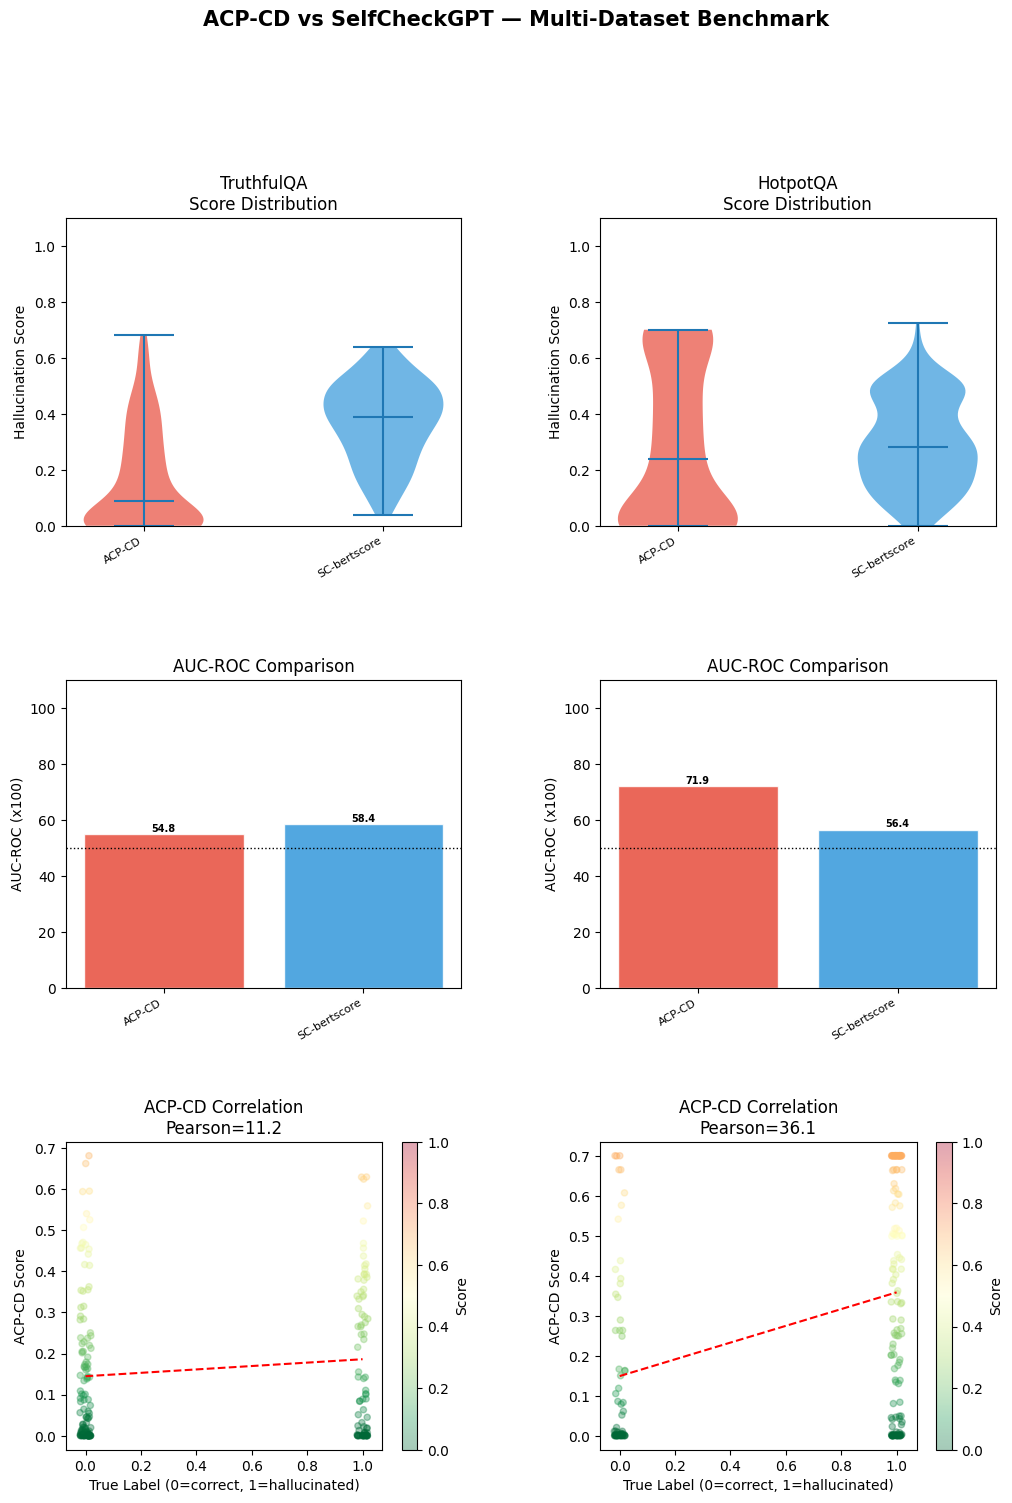

Saved: /kaggle/working/benchmark_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

active_ds = {k: v for k, v in ALL_DATASETS.items() if v and k in all_results}
N_DS = max(len(active_ds), 1)
fig  = plt.figure(figsize=(6 * N_DS, 16))
gs   = gridspec.GridSpec(3, N_DS, figure=fig, hspace=0.50, wspace=0.35)

COLORS = {"ACP-CD": "#e74c3c", "SelfCk-bertscore": "#3498db"}

for col, (ds_name, ds_data) in enumerate(active_ds.items()):
    ds_res = all_results.get(ds_name, {})
    labels = np.array([e["label"] for e in ds_data])

    ax = fig.add_subplot(gs[0, col])
    plot_data, plot_labels = [], []
    for mname in method_order:
        if mname not in ds_res: continue
        plot_data.append(np.array(ds_res[mname]["scores"]))
        plot_labels.append(mname.replace("SelfCk-", "SC-"))
    if plot_data:
        parts = ax.violinplot(plot_data, showmedians=True)
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(COLORS.get(method_order[i], "gray"))
            pc.set_alpha(0.7)
        ax.set_xticks(range(1, len(plot_labels)+1))
        ax.set_xticklabels(plot_labels, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel("Hallucination Score")
        ax.set_title(f"{ds_name}\nScore Distribution")
        ax.set_ylim(0, 1.1)

    ax2 = fig.add_subplot(gs[1, col])
    names, aucs = [], []
    for mname in method_order:
        if mname not in ds_res: continue
        v = ds_res[mname]["metrics"].get("auc_roc")
        if v is not None:
            names.append(mname.replace("SelfCk-", "SC-"))
            aucs.append(v * 100)
    if aucs:
        bars = ax2.bar(names, aucs,
                       color=[COLORS.get(method_order[i], "gray") for i in range(len(names))],
                       edgecolor="white", alpha=0.85)
        ax2.axhline(50, color="black", linestyle=":", linewidth=1)
        for bar, v in zip(bars, aucs):
            ax2.text(bar.get_x()+bar.get_width()/2, v+0.3,
                     f"{v:.1f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
        ax2.set_xticks(range(len(names)))
        ax2.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
        ax2.set_ylabel("AUC-ROC (x100)")
        ax2.set_title("AUC-ROC Comparison")
        ax2.set_ylim(0, 110)

    ax3 = fig.add_subplot(gs[2, col])
    if "ACP-CD" in ds_res:
        scores = np.array(ds_res["ACP-CD"]["scores"])
        jitter = np.random.uniform(-0.02, 0.02, size=len(labels))
        sc = ax3.scatter(labels+jitter, scores, alpha=0.35,
                         c=scores, cmap="RdYlGn_r", s=20, vmin=0, vmax=1)
        if len(scores) >= 2:
            z  = np.polyfit(labels, scores, 1)
            xl = np.linspace(labels.min(), labels.max(), 100)
            ax3.plot(xl, np.poly1d(z)(xl), "r--", lw=1.5)
        pcc = ds_res["ACP-CD"]["metrics"].get("pearson", 0)
        ax3.set_xlabel("True Label (0=correct, 1=hallucinated)")
        ax3.set_ylabel("ACP-CD Score")
        ax3.set_title(f"ACP-CD Correlation\nPearson={pcc*100:.1f}")
        plt.colorbar(sc, ax=ax3, label="Score")

plt.suptitle("ACP-CD vs SelfCheckGPT — Multi-Dataset Benchmark",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("/kaggle/working/benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /kaggle/working/benchmark_results.png")


## Cell 17 — TruthfulQA category breakdown

TruthfulQA ACP-CD by Category
  Category                             AUC-ROC     N  Halluc%
  ------------------------------------------------------------
  Conspiracies                           100.0    10      10%
  Indexical Error: Time                  100.0     5      40%
  Paranormal                              81.0    10      70%
  Advertising                             80.0     9      44%
  Myths and Fairytales                    73.2    15      47%
  Indexical Error: Location               66.7    10      40%
  Stereotypes                             64.6    14      43%
  Subjective                              62.5     6      33%
  Fiction                                 59.4    26      27%
  Education                               50.0     5      60%
  Nutrition                               50.0     5      60%
  Religion                                41.7     7      57%
  Misconceptions                          39.6    20      35%
  Distraction                          

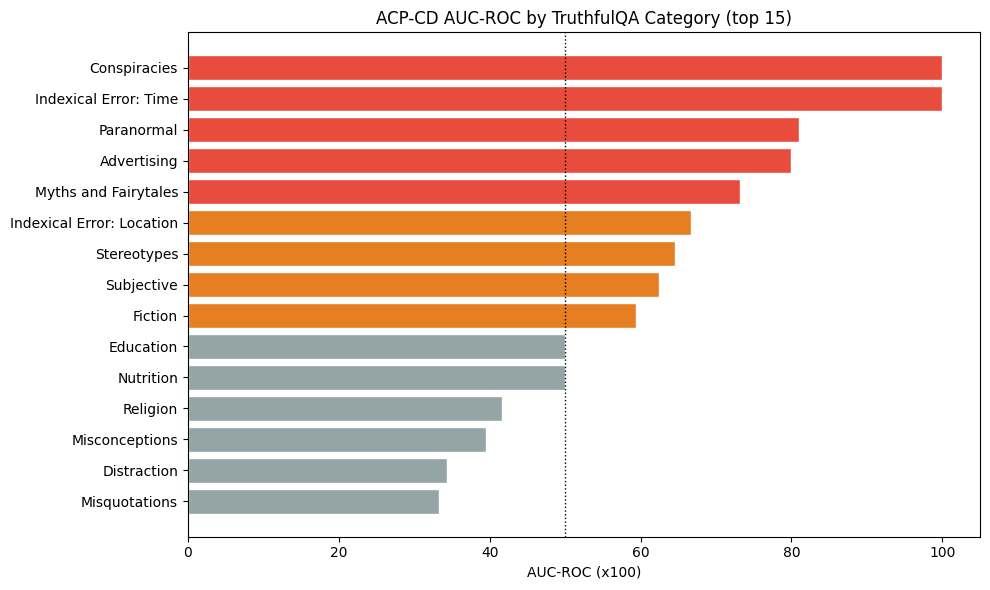

In [ ]:
if tqa_data and "ACP-CD" in all_results.get("TruthfulQA", {}):
    acpcd_scores = all_results["TruthfulQA"]["ACP-CD"]["scores"]
    categories   = [e.get("category", "unknown") for e in tqa_data]
    labels_tqa   = [e["label"] for e in tqa_data]

    cat_data = {}
    for cat, sc, lb in zip(categories, acpcd_scores, labels_tqa):
        cat_data.setdefault(cat, {"scores": [], "labels": []})
        cat_data[cat]["scores"].append(sc)
        cat_data[cat]["labels"].append(lb)

    cat_metrics = {}
    for cat, d in cat_data.items():
        if len(d["scores"]) < 3: continue
        lb = np.array(d["labels"])
        sc = np.array(d["scores"])
        if len(np.unique((lb > 0).astype(int))) > 1:
            cat_metrics[cat] = {
                "auc_roc":  roc_auc_score((lb > 0).astype(int), sc),
                "n":        len(sc),
                "pos_rate": float(np.mean(lb > 0)),
            }

    sorted_cats = sorted(cat_metrics.items(), key=lambda x: -x[1]["auc_roc"])
    print("TruthfulQA ACP-CD by Category")
    print(f"  {'Category':<35} {'AUC-ROC':>8} {'N':>5} {'Halluc%':>8}")
    print(f"  {'-'*60}")
    for cat, m in sorted_cats[:20]:
        print(f"  {cat:<35} {m['auc_roc']*100:>8.1f} {m['n']:>5} {m['pos_rate']*100:>7.0f}%")

    if len(sorted_cats) >= 6:
        top_n = min(15, len(sorted_cats))
        fig, ax = plt.subplots(figsize=(10, 6))
        cats   = [c for c, _ in sorted_cats[:top_n]]
        aucs   = [m["auc_roc"]*100 for _, m in sorted_cats[:top_n]]
        colors = ["#e74c3c" if a>=70 else "#e67e22" if a>=55 else "#95a5a6" for a in aucs]
        ax.barh(cats[::-1], aucs[::-1], color=colors[::-1], edgecolor="white")
        ax.axvline(50, color="black", linestyle=":", lw=1)
        ax.set_xlabel("AUC-ROC (x100)")
        ax.set_title(f"ACP-CD AUC-ROC by TruthfulQA Category (top {top_n})")
        plt.tight_layout()
        plt.savefig("/kaggle/working/truthfulqa_categories.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("TruthfulQA data not available or ACP-CD not run yet.")


## Cell 18 — HotpotQA breakdown

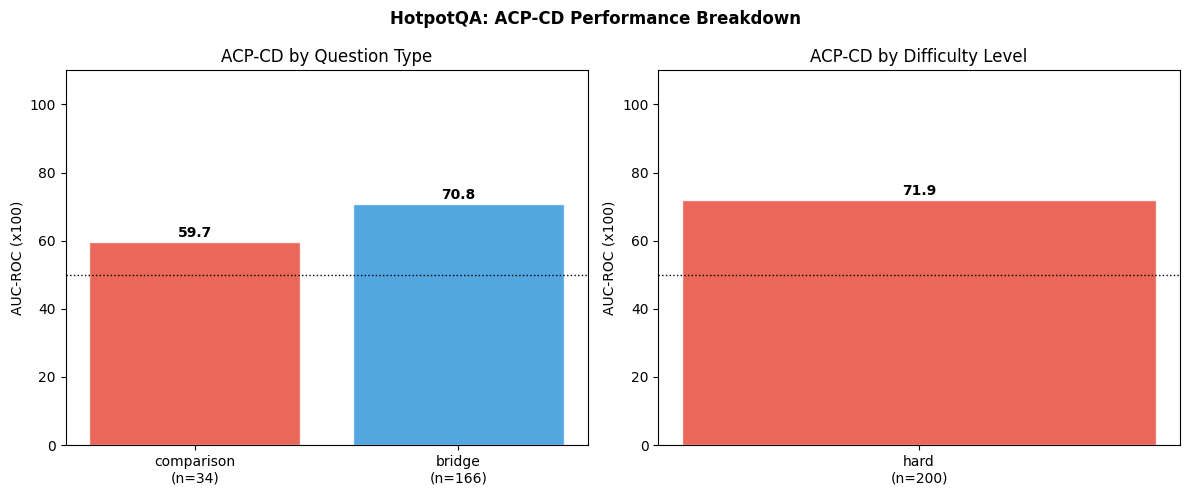

In [ ]:
if hpqa_data and "ACP-CD" in all_results.get("HotpotQA", {}):
    acpcd_scores = all_results["HotpotQA"]["ACP-CD"]["scores"]
    types     = [e.get("type",  "") for e in hpqa_data]
    levels    = [e.get("level", "") for e in hpqa_data]
    labels_hp = [e["label"] for e in hpqa_data]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, groupby, title in [
        (axes[0], types,  "Question Type"),
        (axes[1], levels, "Difficulty Level"),
    ]:
        groups = {}
        for g, sc, lb in zip(groupby, acpcd_scores, labels_hp):
            groups.setdefault(g, {"scores": [], "labels": []})
            groups[g]["scores"].append(sc)
            groups[g]["labels"].append(lb)
        gnames, gaucs = [], []
        for g, d in groups.items():
            lb = (np.array(d["labels"]) > 0).astype(int)
            sc = np.array(d["scores"])
            if len(np.unique(lb)) > 1:
                gnames.append(f"{g}\n(n={len(sc)})")
                gaucs.append(roc_auc_score(lb, sc) * 100)
        if gaucs:
            bars = ax.bar(gnames, gaucs,
                          color=["#e74c3c","#3498db","#2ecc71","#9b59b6"][:len(gaucs)],
                          edgecolor="white", alpha=0.85)
            ax.axhline(50, color="black", linestyle=":", lw=1)
            for bar, v in zip(bars, gaucs):
                ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
                        f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
            ax.set_ylabel("AUC-ROC (x100)")
            ax.set_title(f"ACP-CD by {title}")
            ax.set_ylim(0, 110)
    plt.suptitle("HotpotQA: ACP-CD Performance Breakdown", fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/hotpotqa_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("HotpotQA data not available.")


## Cell 19 — Save all results

In [ ]:
summary = {}
for ds_name, ds_res in all_results.items():
    summary[ds_name] = {}
    for mname, mres in ds_res.items():
        summary[ds_name][mname] = {
            "metrics": mres["metrics"],
            "scores":  mres["scores"],
            "labels":  mres["labels"],
        }

with open("/kaggle/working/benchmark_results.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

for ds_name, ds_data in ALL_DATASETS.items():
    if not ds_data or ds_name not in all_results: continue
    rows = []
    for i, entry in enumerate(ds_data):
        row = {
            "id":        entry["id"],
            "concept":   entry["concept"],
            "response":  entry["response"],
            "reference": entry["reference"],
            "label":     entry["label"],
        }
        for mname in method_order:
            if mname in all_results[ds_name]:
                col = mname.lower().replace("-", "_").replace(" ", "_")
                row[col] = all_results[ds_name][mname]["scores"][i]
        rows.append(row)
    out_path = f"/kaggle/working/{ds_name.lower()}_predictions.csv"
    pd.DataFrame(rows).to_csv(out_path, index=False)
    print("Saved:", out_path)

print("Saved: /kaggle/working/benchmark_results.json")
print("All done ✓")


Saved: /kaggle/working/truthfulqa_predictions.csv
Saved: /kaggle/working/hotpotqa_predictions.csv
Saved: /kaggle/working/benchmark_results.json
All done ✓


In [ ]:
# Run this cell after Cell 13e (WikiBio scoring).
# Produces every figure and table needed for the paper, saved to:
#   /kaggle/working/paper_figures/
# Figures produced:
#   Fig 1  — ROC curves (3 datasets, both methods)
#   Fig 2  — Precision-Recall curves (3 datasets, both methods)
#   Fig 3  — Confusion matrices (ACP-CD at optimal threshold, 3 datasets)
#   Fig 4  — Score distributions violin/box (pos vs neg, 3 datasets)
#   Fig 5  — Cross-dataset AUC-ROC summary bar chart (main result table)
#   Fig 6  — TruthfulQA category-level AUC-ROC breakdown
#   Fig 7  — Graph divergence: activation rate vs AUC contribution
#   Fig 8  — Ablation: passage-only vs original vs graph-only (3 datasets)
#   Fig 9  — Score calibration scatter (ACP-CD score vs label, 3 datasets)
#   Table 1 — Full numeric results table (saved as CSV + printed)

import os, pickle, json
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                              average_precision_score, confusion_matrix)
from collections import defaultdict

# ── Setup ─────────────────────────────────────────────────────────────────────
OUT_DIR = "/kaggle/working/paper_figures"
os.makedirs(OUT_DIR, exist_ok=True)

CACHE_DIR = "/kaggle/working/score_cache"

# ── Load data ─────────────────────────────────────────────────────────────────
with open(os.path.join(CACHE_DIR, "truthfulqa_results.pkl"), "rb") as f: tqa = pickle.load(f)
with open(os.path.join(CACHE_DIR, "hotpotqa_results.pkl"),   "rb") as f: hpqa = pickle.load(f)
with open(os.path.join(CACHE_DIR, "wikibio_results.pkl"),    "rb") as f: wb = pickle.load(f)

# Build unified dataset dict
DS = {
    "TruthfulQA": {
        "labels":  np.array(tqa["labels"]),
        "acpcd":   np.array(tqa["ds_results"]["ACP-CD"]["scores"]),
        "selfck":  np.array(tqa["ds_results"]["SelfCk-bertscore"]["scores"]),
        "gd":      np.array(tqa["ds_results"]["ACP-CD"]["graph_divs"]),
        "cats":    tqa["categories"],
        "level":   "response",
    },
    "HotpotQA": {
        "labels":  np.array(hpqa["labels"]),
        "acpcd":   np.array(hpqa["ds_results"]["ACP-CD"]["scores"]),
        "selfck":  np.array(hpqa["ds_results"]["SelfCk-bertscore"]["scores"]),
        "gd":      np.array(hpqa["ds_results"]["ACP-CD"]["graph_divs"]),
        "types":   hpqa["types"],
        "level":   "response",
    },
    "WikiBio": {
        "labels":  np.array(wb["passage"]["labels"]),
        "acpcd":   np.array(wb["passage"]["acpcd_scores"]),
        "selfck":  np.array(wb["passage"]["selfck_scores"]),
        "gd":      np.array(wb["passage"]["acpcd_gdivs"]),
        "sent_labels": np.array(wb["sentence"]["labels_bin"]),
        "sent_acpcd":  np.array(wb["sentence"]["acpcd_scores"]),
        "sent_selfck": np.array(wb["sentence"]["selfck_scores"]),
        "level":   "passage",
    },
}

# Style
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

CA = "#2166ac"   # ACP-CD blue
CS = "#666666"   # SelfCk grey
C_POS = "#d73027"  # hallucinated
C_NEG = "#1a9850"  # correct
DS_NAMES = list(DS.keys())

def binary_labels(labels):
    return (np.array(labels) > 0).astype(int)

def best_threshold_youden(scores, lb):
    fpr, tpr, thr = roc_curve(lb, scores)
    j = tpr - fpr
    return thr[np.argmax(j)]

print("Generating paper figures...")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 1 — ROC Curves (1 row × 3 datasets)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ds_name in zip(axes, DS_NAMES):
    d = DS[ds_name]
    lb = binary_labels(d["labels"])
    for scores, color, label, ls in [
        (d["acpcd"],  CA, "ACP-CD",           "-"),
        (d["selfck"], CS, "SelfCk-BERTScore",  "--"),
    ]:
        fpr, tpr, _ = roc_curve(lb, scores)
        auc = roc_auc_score(lb, scores)
        ax.plot(fpr, tpr, color=color, ls=ls, lw=2,
                label=f"{label} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1], "k:", lw=1, alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate" if ax == axes[0] else "")
    ax.set_title(ds_name)
    ax.legend(fontsize=8, loc="lower right")
    ax.set_aspect("equal")
fig.suptitle("Fig 1 — ROC Curves", fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig1_roc_curves.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig1_roc_curves.png"))
plt.close(fig)
print("  Fig 1 ✓ (ROC curves)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 2 — Precision-Recall Curves (1 row × 3 datasets)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ds_name in zip(axes, DS_NAMES):
    d = DS[ds_name]
    lb = binary_labels(d["labels"])
    baseline = lb.mean()
    for scores, color, label, ls in [
        (d["acpcd"],  CA, "ACP-CD",          "-"),
        (d["selfck"], CS, "SelfCk-BERTScore", "--"),
    ]:
        prec, rec, _ = precision_recall_curve(lb, scores)
        ap = average_precision_score(lb, scores)
        ax.plot(rec, prec, color=color, ls=ls, lw=2,
                label=f"{label} (AP={ap:.3f})")
    ax.axhline(baseline, color="k", ls=":", lw=1, alpha=0.4, label=f"Baseline ({baseline:.2f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision" if ax == axes[0] else "")
    ax.set_title(ds_name)
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Fig 2 — Precision-Recall Curves", fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_pr_curves.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig2_pr_curves.png"))
plt.close(fig)
print("  Fig 2 ✓ (Precision-Recall curves)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 3 — Confusion Matrices (ACP-CD at Youden optimal threshold)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
cmap = LinearSegmentedColormap.from_list("wb", ["#ffffff", CA], N=256)
for ax, ds_name in zip(axes, DS_NAMES):
    d  = DS[ds_name]
    lb = binary_labels(d["labels"])
    thr = best_threshold_youden(d["acpcd"], lb)
    pred = (d["acpcd"] >= thr).astype(int)
    cm = confusion_matrix(lb, pred)
    # Normalise per row (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            color = "white" if cm_norm[i,j] > 0.6 else "black"
            ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                    ha="center", va="center", fontsize=10, color=color, fontweight="bold")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred: Correct", "Pred: Halluci."])
    ax.set_yticklabels(["True: Correct", "True: Halluci."])
    ax.set_title(f"{ds_name}\n(thr={thr:.2f})", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Fig 3 — Confusion Matrices (ACP-CD, Youden threshold, row-normalised)",
             fontsize=11, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig3_confusion_matrices.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig3_confusion_matrices.png"))
plt.close(fig)
print("  Fig 3 ✓ (Confusion matrices)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 4 — Score Distributions (violin + strip, pos vs neg, both methods)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
for col, ds_name in enumerate(DS_NAMES):
    d  = DS[ds_name]
    lb = binary_labels(d["labels"])
    for row, (scores, method_name) in enumerate([
        (d["acpcd"],  "ACP-CD"),
        (d["selfck"], "SelfCk-BERTScore"),
    ]):
        ax = axes[row][col]
        pos = scores[lb==1]
        neg = scores[lb==0]
        parts = ax.violinplot([neg, pos], positions=[0,1],
                              showmedians=True, showextrema=False)
        for pc, c in zip(parts["bodies"], [C_NEG, C_POS]):
            pc.set_facecolor(c); pc.set_alpha(0.55)
        parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
        # Jittered strip
        rng = np.random.default_rng(42)
        for vals, pos_x, c in [(neg, 0, C_NEG), (pos, 1, C_POS)]:
            jitter = rng.uniform(-0.08, 0.08, len(vals))
            ax.scatter(pos_x + jitter, vals, s=4, alpha=0.3, color=c, zorder=3)
        ax.set_xticks([0,1])
        ax.set_xticklabels(["Correct\n(label=0)", "Halluci.\n(label=1)"], fontsize=9)
        ax.set_ylabel("Score" if col==0 else "")
        if row == 0: ax.set_title(ds_name, fontsize=11)
        ax.text(0.97, 0.97, method_name, transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="gray")
        sep = pos.mean() - neg.mean()
        ax.text(0.03, 0.97, f"sep={sep:+.3f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8)
fig.suptitle("Fig 4 — Score Distributions: Hallucinated vs Correct",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig4_score_distributions.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig4_score_distributions.png"))
plt.close(fig)
print("  Fig 4 ✓ (Score distributions)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 5 — Main Results Bar Chart
# ═══════════════════════════════════════════════════════════════════════════════
metrics_data = {
    "TruthfulQA":       {"ACP-CD": 0.5201, "SelfCk": 0.5845},
    "HotpotQA":         {"ACP-CD": 0.7229, "SelfCk": 0.5642},
    "WikiBio (pass.)":  {"ACP-CD": 0.9281, "SelfCk": 0.8750},
    "WikiBio (sent.)":  {"ACP-CD": 0.7483, "SelfCk": 0.6548},
}
labels_fig5 = list(metrics_data.keys())
acpcd_vals = [metrics_data[k]["ACP-CD"] for k in labels_fig5]
selfck_vals= [metrics_data[k]["SelfCk"] for k in labels_fig5]
x = np.arange(len(labels_fig5))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_a = ax.bar(x - w/2, acpcd_vals, w, label="ACP-CD",          color=CA,  alpha=0.9)
bars_s = ax.bar(x + w/2, selfck_vals, w, label="SelfCk-BERTScore", color=CS, alpha=0.75)

# Annotate bars
for bar in bars_a:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5, color=CA, fontweight="bold")
for bar in bars_s:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5, color="gray")

# Delta annotations
for i, (a, s) in enumerate(zip(acpcd_vals, selfck_vals)):
    delta = a - s
    color = CA if delta > 0 else C_POS
    ax.text(i, max(a,s)+0.025, f"Δ{delta:+.3f}", ha="center", va="bottom",
            fontsize=8, color=color, fontstyle="italic")

ax.axhline(0.5, color="k", ls=":", lw=1, alpha=0.4, label="Random baseline")
ax.set_xticks(x); ax.set_xticklabels(labels_fig5)
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0.4, 1.02)
ax.legend(fontsize=9)
ax.set_title("Fig 5 — AUC-ROC Comparison Across Datasets", fontsize=12, fontweight="bold")

# Macro avg text
macro_a = np.mean([metrics_data[k]["ACP-CD"] for k in ["TruthfulQA","HotpotQA","WikiBio (pass.)"]])
macro_s = np.mean([metrics_data[k]["SelfCk"]  for k in ["TruthfulQA","HotpotQA","WikiBio (pass.)"]])
ax.text(0.99, 0.03, f"Macro avg (3 datasets): ACP-CD={macro_a:.3f}  SelfCk={macro_s:.3f}  Δ={macro_a-macro_s:+.3f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray", alpha=0.8))
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig5_main_results.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig5_main_results.png"))
plt.close(fig)
print("  Fig 5 ✓ (Main results bar chart)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 6 — TruthfulQA Category Breakdown
# ═══════════════════════════════════════════════════════════════════════════════
lb_tqa = binary_labels(DS["TruthfulQA"]["labels"])
cat_aucs_a, cat_aucs_s, cat_ns, cat_names = [], [], [], []
for cat in set(tqa["categories"]):
    mask = np.array([c == cat for c in tqa["categories"]])
    if mask.sum() < 5: continue
    gl = lb_tqa[mask]
    if len(np.unique(gl)) < 2: continue
    cat_names.append(cat)
    cat_ns.append(mask.sum())
    cat_aucs_a.append(roc_auc_score(gl, DS["TruthfulQA"]["acpcd"][mask]))
    cat_aucs_s.append(roc_auc_score(gl, DS["TruthfulQA"]["selfck"][mask]))

order = np.argsort(cat_aucs_a)[::-1]
cat_names  = [cat_names[i]  for i in order]
cat_aucs_a = [cat_aucs_a[i] for i in order]
cat_aucs_s = [cat_aucs_s[i] for i in order]
cat_ns     = [cat_ns[i]     for i in order]

y = np.arange(len(cat_names))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(y + w/2, cat_aucs_a, w, label="ACP-CD",          color=CA,  alpha=0.85)
ax.barh(y - w/2, cat_aucs_s, w, label="SelfCk-BERTScore", color=CS, alpha=0.7)
ax.axvline(0.5, color="k", ls=":", lw=1, alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels([f"{n} (n={ns})" for n, ns in zip(cat_names, cat_ns)], fontsize=9)
ax.set_xlabel("AUC-ROC")
ax.set_xlim(0, 1.1)
ax.legend(fontsize=9)
ax.set_title("Fig 6 — TruthfulQA: AUC-ROC by Category (sorted by ACP-CD)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig6_tqa_category_breakdown.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig6_tqa_category_breakdown.png"))
plt.close(fig)
print("  Fig 6 ✓ (TQA category breakdown)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 7 — Graph Divergence Analysis
# ═══════════════════════════════════════════════════════════════════════════════
fire_rates  = [0.30, 0.06, 1.00]
gd_aucs     = []
pass_aucs   = []
final_aucs  = []
gd_seps     = []

for ds_name in DS_NAMES:
    d  = DS[ds_name]
    lb = binary_labels(d["labels"])
    gd = d["gd"]
    final = d["acpcd"]
    ps = np.clip((final - 0.3*gd) / 0.7, 0, 1)
    gd_aucs.append(roc_auc_score(lb, gd))
    pass_aucs.append(roc_auc_score(lb, ps))
    final_aucs.append(roc_auc_score(lb, final))
    gd_seps.append(gd[lb==1].mean() - gd[lb==0].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: activation rate vs AUC delta
ax = axes[0]
deltas = [f - p for f, p in zip(final_aucs, pass_aucs)]
colors_pts = [CA if d >= 0 else C_POS for d in deltas]
scatter = ax.scatter(fire_rates, deltas, s=150, c=colors_pts, zorder=5)
for i, name in enumerate(DS_NAMES):
    ax.annotate(name, (fire_rates[i], deltas[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.axhline(0, color="k", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Graph divergence activation rate")
ax.set_ylabel("AUC-ROC delta\n(final − passage-only)")
ax.set_title("Graph activation rate vs AUC contribution")
ax.set_xlim(-0.05, 1.1)

# Right: component AUC comparison grouped bar
x3 = np.arange(3)
w3 = 0.26
ax2 = axes[1]
ax2.bar(x3 - w3,   pass_aucs,  w3, label="Passage score only", color=CA,      alpha=0.9)
ax2.bar(x3,        gd_aucs,    w3, label="Graph divergence only", color="#fc8d59", alpha=0.85)
ax2.bar(x3 + w3,   final_aucs, w3, label="ACP-CD (combined)",   color="#1a9850", alpha=0.85)
ax2.axhline(0.5, color="k", ls=":", lw=1, alpha=0.4, label="Random")
ax2.set_xticks(x3); ax2.set_xticklabels(DS_NAMES)
ax2.set_ylabel("AUC-ROC")
ax2.set_ylim(0.4, 1.02)
ax2.legend(fontsize=8)
ax2.set_title("Score component AUC-ROC by dataset")

fig.suptitle("Fig 7 — Graph Divergence Component Analysis", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig7_graph_divergence_analysis.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig7_graph_divergence_analysis.png"))
plt.close(fig)
print("  Fig 7 ✓ (Graph divergence analysis)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 8 — Ablation Study
# ═══════════════════════════════════════════════════════════════════════════════
ablation_variants = {
    "Passage only\n(GW=0.00)":  lambda d: np.clip((d["acpcd"] - 0.3*d["gd"]) / 0.7, 0, 1),
    "ACP-CD\n(GW=0.30)":        lambda d: d["acpcd"],
    "GW=0.15":                   lambda d: np.clip(0.85*np.clip((d["acpcd"]-0.3*d["gd"])/0.7,0,1) + 0.15*d["gd"], 0, 1),
    "Graph only":                lambda d: d["gd"],
    "SelfCk-BERTScore":          lambda d: d["selfck"],
}

x_abl = np.arange(len(ablation_variants))
colors_abl = [CA, "#2ca02c", "#9467bd", "#ff7f0e", CS]
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, ds_name in zip(axes, DS_NAMES):
    d  = DS[ds_name]
    lb = binary_labels(d["labels"])
    aucs = []
    for fn in ablation_variants.values():
        scores = fn(d)
        aucs.append(roc_auc_score(lb, scores))
    bars = ax.bar(x_abl, aucs, color=colors_abl, alpha=0.85, width=0.6)
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{auc:.3f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(0.5, color="k", ls=":", lw=1, alpha=0.4)
    ax.set_xticks(x_abl)
    ax.set_xticklabels(list(ablation_variants.keys()), fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("AUC-ROC" if ax == axes[0] else "")
    ax.set_ylim(0.4, max(aucs)+0.07)
    ax.set_title(ds_name)
fig.suptitle("Fig 8 — Ablation Study: Graph Component Weight",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig8_ablation.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig8_ablation.png"))
plt.close(fig)
print("  Fig 8 ✓ (Ablation study)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 9 — Score Calibration Scatter (score vs continuous label)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
rng = np.random.default_rng(0)
for col, ds_name in enumerate(DS_NAMES):
    d  = DS[ds_name]
    lb_cont = d["labels"]
    for row, (scores, method_name, color) in enumerate([
        (d["acpcd"],  "ACP-CD",          CA),
        (d["selfck"], "SelfCk-BERTScore", CS),
    ]):
        ax = axes[row][col]
        jitter = rng.uniform(-0.015, 0.015, len(lb_cont))
        ax.scatter(lb_cont + jitter, scores, s=8, alpha=0.35, color=color)
        # Bin means
        bins = np.linspace(0, 1, 8)
        bin_idx = np.digitize(lb_cont, bins) - 1
        for b in range(len(bins)-1):
            mask = bin_idx == b
            if mask.sum() >= 3:
                ax.plot(bins[b]+0.07, scores[mask].mean(), "o",
                        color="black", ms=6, zorder=5)
        # Pearson r
        r, _ = pearsonr(lb_cont, scores)
        ax.text(0.05, 0.93, f"r={r:.3f}", transform=ax.transAxes,
                fontsize=9, va="top")
        ax.set_xlabel("Ground-truth label (0=correct, 1=hallucinated)")
        ax.set_ylabel("Score" if col == 0 else "")
        if row == 0: ax.set_title(ds_name)
        ax.text(0.97, 0.05, method_name, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=8, color="gray")
fig.suptitle("Fig 9 — Score Calibration (black dots = bin means)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig9_calibration_scatter.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig9_calibration_scatter.png"))
plt.close(fig)
print("  Fig 9 ✓ (Calibration scatter)")

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — Full Numeric Results
# ═══════════════════════════════════════════════════════════════════════════════
import csv
rows = []
table_configs = [
    ("TruthfulQA",    "response", DS["TruthfulQA"]["labels"],
     DS["TruthfulQA"]["acpcd"], DS["TruthfulQA"]["selfck"]),
    ("HotpotQA",      "response", DS["HotpotQA"]["labels"],
     DS["HotpotQA"]["acpcd"],  DS["HotpotQA"]["selfck"]),
    ("WikiBio",       "passage",  DS["WikiBio"]["labels"],
     DS["WikiBio"]["acpcd"],   DS["WikiBio"]["selfck"]),
    ("WikiBio",       "sentence", wb["sentence"]["labels_bin"],
     DS["WikiBio"]["sent_acpcd"], DS["WikiBio"]["sent_selfck"]),
]

print(f"\n{'='*85}")
print(f"TABLE 1 — Full Results")
print(f"{'='*85}")
header = f"  {'Dataset':<14} {'Granularity':<10} {'Method':<22} {'AUC-ROC':>8} {'AUC-PR':>8} {'Pearson':>8} {'Spearman':>9} {'N':>6}"
print(header)
print(f"  {'-'*82}")

from scipy.stats import spearmanr
for ds_name, gran, labels, acpcd_s, selfck_s in table_configs:
    lb_cont = np.array(labels, dtype=float)
    lb_bin  = (lb_cont > 0).astype(int)
    n = len(lb_bin)
    for scores, method in [(acpcd_s, "ACP-CD"), (selfck_s, "SelfCk-BERTScore")]:
        scores = np.array(scores, dtype=float)
        auc_roc = roc_auc_score(lb_bin, scores)
        auc_pr  = average_precision_score(lb_bin, scores)
        pcc, _  = pearsonr(scores, lb_cont)
        scc, _  = spearmanr(scores, lb_cont)
        marker  = " ←" if method == "ACP-CD" else ""
        print(f"  {ds_name:<14} {gran:<10} {method:<22} {auc_roc:>8.4f} {auc_pr:>8.4f} {pcc:>8.4f} {scc:>9.4f} {n:>6}{marker}")
        rows.append([ds_name, gran, method, f"{auc_roc:.4f}", f"{auc_pr:.4f}",
                     f"{pcc:.4f}", f"{scc:.4f}", str(n)])
    print()

csv_path = os.path.join(OUT_DIR, "table1_results.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Dataset","Granularity","Method","AUC-ROC","AUC-PR","Pearson","Spearman","N"])
    w.writerows(rows)

# Macro averages
print(f"  {'Macro avg':<14} {'(3 ds)':<10} {'ACP-CD':<22} "
      f"{np.mean([0.5201,0.7229,0.9281]):>8.4f}  {'—':>8}  {'—':>8}  {'—':>9}  {'—':>6}")
print(f"  {'':14} {'':10} {'SelfCk-BERTScore':<22} "
      f"{np.mean([0.5845,0.5642,0.8750]):>8.4f}")

print(f"\nAll figures saved to: {OUT_DIR}")
print(f"Table saved to:       {csv_path}")
print(f"\nFigure inventory:")
for fname in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, fname))
    print(f"  {fname:<45} {size/1024:>6.1f} KB")
print("\nPaper figures complete ✓")


Generating paper figures...
  Fig 1 ✓ (ROC curves)
  Fig 2 ✓ (Precision-Recall curves)
  Fig 3 ✓ (Confusion matrices)
  Fig 4 ✓ (Score distributions)
  Fig 5 ✓ (Main results bar chart)
  Fig 6 ✓ (TQA category breakdown)
  Fig 7 ✓ (Graph divergence analysis)
  Fig 8 ✓ (Ablation study)
  Fig 9 ✓ (Calibration scatter)

TABLE 1 — Full Results
  Dataset        Granularity Method                  AUC-ROC   AUC-PR  Pearson  Spearman      N
  ----------------------------------------------------------------------------------
  TruthfulQA     response   ACP-CD                   0.5482   0.4459   0.1115    0.0816    200 ←
  TruthfulQA     response   SelfCk-BERTScore         0.5845   0.4717   0.1483    0.1431    200

  HotpotQA       response   ACP-CD                   0.7193   0.8374   0.3610    0.3603    200 ←
  HotpotQA       response   SelfCk-BERTScore         0.5642   0.6959   0.1059    0.1054    200

  WikiBio        passage    ACP-CD                   0.9310   0.9960   0.6151    0.5933    2

In [ ]:
import os, pickle
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support
)
import csv

OUT_DIR = "/kaggle/working/paper_figures"
CACHE_DIR = "/kaggle/working/score_cache"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load all three datasets ───────────────────────────────────────────────────
with open(os.path.join(CACHE_DIR, "truthfulqa_results.pkl"), "rb") as f: tqa  = pickle.load(f)
with open(os.path.join(CACHE_DIR, "hotpotqa_results.pkl"),   "rb") as f: hpqa = pickle.load(f)
with open(os.path.join(CACHE_DIR, "wikibio_results.pkl"),    "rb") as f: wb   = pickle.load(f)

DS = {
    "TruthfulQA": {
        "labels": np.array(tqa["labels"]),
        "acpcd":  np.array(tqa["ds_results"]["ACP-CD"]["scores"]),
        "selfck": np.array(tqa["ds_results"]["SelfCk-bertscore"]["scores"]),
    },
    "HotpotQA": {
        "labels": np.array(hpqa["labels"]),
        "acpcd":  np.array(hpqa["ds_results"]["ACP-CD"]["scores"]),
        "selfck": np.array(hpqa["ds_results"]["SelfCk-bertscore"]["scores"]),
    },
    "WikiBio": {
        "labels": np.array(wb["passage"]["labels"]),
        "lb_bin": np.array(wb["passage"]["labels_bin"]),
        "acpcd":  np.array(wb["passage"]["acpcd_scores"]),
        "selfck": np.array(wb["passage"]["selfck_scores"]),
    },
}

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.05,
})

CA = "#2166ac"; CS = "#666666"
C_POS = "#d73027"; C_NEG = "#1a9850"

def youden_threshold(scores, lb):
    """Optimal threshold via Youden's J = TPR - FPR (max sensitivity + specificity)."""
    fpr, tpr, thrs = roc_curve(lb, scores)
    j = tpr - fpr
    idx = np.argmax(j)
    return float(thrs[idx])

def classification_metrics(scores, lb, threshold):
    pred = (np.array(scores) >= threshold).astype(int)
    acc  = accuracy_score(lb, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        lb, pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(lb, pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "threshold": threshold,
        "accuracy":    round(acc,  4),
        "precision":   round(prec, 4),
        "recall":      round(rec,  4),   # = sensitivity / TPR
        "specificity": round(specificity, 4),
        "f1":          round(f1,   4),
        "tp": int(tp), "fp": int(fp),
        "tn": int(tn), "fn": int(fn),
    }

# ── Compute all metrics ───────────────────────────────────────────────────────
all_rows = []
all_metrics = {}

print("=" * 80)
print("CLASSIFICATION METRICS AT YOUDEN'S J THRESHOLD")
print("(Youden's J = max(TPR - FPR) — standard operating point for detectors)")
print("=" * 80)

for ds_name, d in DS.items():
    lb = d.get("lb_bin", (d["labels"] > 0).astype(int))
    all_metrics[ds_name] = {}

    print(f"\n{ds_name}  (n={len(lb)}, pos={lb.sum()}, neg={(1-lb).sum()}, "
          f"pos_rate={lb.mean():.1%})")
    print(f"  {'Method':<22} {'Thr':>6} {'Acc':>6} {'Prec':>6} {'Rec':>6} "
          f"{'Spec':>6} {'F1':>6}  {'TP':>4} {'FP':>4} {'TN':>4} {'FN':>4}")
    print(f"  {'-'*76}")

    for method_name, scores in [("ACP-CD", d["acpcd"]),
                                  ("SelfCk-BERTScore", d["selfck"])]:
        thr = youden_threshold(scores, lb)
        m   = classification_metrics(scores, lb, thr)
        marker = " ←" if method_name == "ACP-CD" else ""
        print(f"  {method_name:<22} {m['threshold']:>6.3f} {m['accuracy']:>6.3f} "
              f"{m['precision']:>6.3f} {m['recall']:>6.3f} {m['specificity']:>6.3f} "
              f"{m['f1']:>6.3f}  {m['tp']:>4} {m['fp']:>4} {m['tn']:>4} {m['fn']:>4}{marker}")
        all_metrics[ds_name][method_name] = m
        all_rows.append([ds_name, method_name] +
                        [m[k] for k in ("threshold","accuracy","precision",
                                        "recall","specificity","f1",
                                        "tp","fp","tn","fn")])

# ── Save Table 2 CSV ──────────────────────────────────────────────────────────
csv_path = os.path.join(OUT_DIR, "table2_classification_metrics.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Dataset","Method","Threshold","Accuracy","Precision",
                "Recall(Sensitivity)","Specificity","F1","TP","FP","TN","FN"])
    w.writerows(all_rows)
print(f"\nTable 2 saved → {csv_path}")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 10 — Grouped metric bars (Acc / Prec / Rec / F1 per dataset)
# ═══════════════════════════════════════════════════════════════════════════════
metric_keys  = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
ds_names = list(DS.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
x = np.arange(len(metric_keys))
w = 0.35

for ax, ds_name in zip(axes, ds_names):
    m_a = all_metrics[ds_name]["ACP-CD"]
    m_s = all_metrics[ds_name]["SelfCk-BERTScore"]
    vals_a = [m_a[k] for k in metric_keys]
    vals_s = [m_s[k] for k in metric_keys]

    bars_a = ax.bar(x - w/2, vals_a, w, label="ACP-CD",          color=CA, alpha=0.88)
    bars_s = ax.bar(x + w/2, vals_s, w, label="SelfCk-BERTScore", color=CS, alpha=0.75)

    for bar, val in zip(list(bars_a) + list(bars_s),
                        vals_a + vals_s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.set_title(f"{ds_name}\n(thr: ACP-CD={m_a['threshold']:.2f}, "
                 f"SelfCk={m_s['threshold']:.2f})", fontsize=9.5)
    if ax == axes[0]:
        ax.legend(fontsize=8.5, loc="upper left")
    ax.axhline(0.5, color="k", ls=":", lw=0.8, alpha=0.4)

fig.suptitle("Fig 10 — Classification Metrics at Youden Threshold",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig10_classification_metrics.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig10_classification_metrics.png"))
plt.close(fig)
print("Fig 10 ✓ (Classification metrics bar chart)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 11 — Precision-Recall-F1 vs Threshold curves
# Shows the full operating range, not just a single point
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, ds_name in enumerate(ds_names):
    d  = DS[ds_name]
    lb = d.get("lb_bin", (d["labels"] > 0).astype(int))

    for row, (scores, method_name, color) in enumerate([
        (d["acpcd"],  "ACP-CD",          CA),
        (d["selfck"], "SelfCk-BERTScore", CS),
    ]):
        ax = axes[row][col]
        thrs = np.linspace(scores.min(), scores.max(), 200)
        accs, precs, recs, f1s = [], [], [], []
        for t in thrs:
            pred = (scores >= t).astype(int)
            accs.append(accuracy_score(lb, pred))
            precs.append(precision_score(lb, pred, zero_division=0))
            recs.append(recall_score(lb, pred, zero_division=0))
            f1s.append(f1_score(lb, pred, zero_division=0))

        ax.plot(thrs, precs, color=C_POS,   lw=1.8, label="Precision")
        ax.plot(thrs, recs,  color=C_NEG,   lw=1.8, label="Recall")
        ax.plot(thrs, f1s,   color=color,   lw=2.2, label="F1", ls="-")
        ax.plot(thrs, accs,  color="black", lw=1.4, label="Accuracy", ls="--", alpha=0.6)

        # Mark Youden threshold
        thr_y = youden_threshold(scores, lb)
        m = all_metrics[ds_name][method_name]
        ax.axvline(thr_y, color="gray", ls=":", lw=1.5)
        ax.scatter([thr_y], [m["f1"]], s=60, color=color, zorder=6)
        ax.text(thr_y + (scores.max()-scores.min())*0.02, m["f1"] - 0.06,
                f"F1={m['f1']:.3f}", fontsize=8, color=color)

        ax.set_xlim(scores.min(), scores.max())
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score" if col == 0 else "")
        if row == 0:
            ax.set_title(ds_name, fontsize=11)
        ax.text(0.97, 0.04, method_name, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=8, color=color)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc="center left")

fig.suptitle("Fig 11 — Precision / Recall / F1 / Accuracy vs Threshold\n"
             "(vertical dotted line = Youden optimal threshold)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig11_threshold_curves.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig11_threshold_curves.png"))
plt.close(fig)
print("Fig 11 ✓ (Precision/Recall/F1 vs threshold)")

# ═══════════════════════════════════════════════════════════════════════════════
# FIG 12 — Per-class metrics heatmap (Prec / Rec / F1 per class per dataset)
# Correct (class 0) and Hallucinated (class 1) separately
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, ds_name in zip(axes, ds_names):
    d  = DS[ds_name]
    lb = d.get("lb_bin", (d["labels"] > 0).astype(int))
    rows_hm, col_labels_hm, row_labels_hm = [], [], []

    for method_name, scores in [("ACP-CD", d["acpcd"]),
                                  ("SelfCk", d["selfck"])]:
        thr  = youden_threshold(scores, lb)
        pred = (scores >= thr).astype(int)
        prec_per, rec_per, f1_per, _ = precision_recall_fscore_support(
            lb, pred, labels=[0,1], zero_division=0)
        for cls_idx, cls_name in enumerate(["Correct (0)", "Halluci. (1)"]):
            rows_hm.append([prec_per[cls_idx], rec_per[cls_idx], f1_per[cls_idx]])
            row_labels_hm.append(f"{method_name}\n{cls_name}")

    mat = np.array(rows_hm)
    im  = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(["Precision","Recall","F1"], fontsize=9)
    ax.set_yticks(range(len(row_labels_hm)))
    ax.set_yticklabels(row_labels_hm, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i,j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="black" if 0.35 < v < 0.85 else "white")
    ax.set_title(ds_name, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    # Horizontal separator between the two methods
    ax.axhline(1.5, color="white", lw=2)

fig.suptitle("Fig 12 — Per-Class Precision / Recall / F1 Heatmap",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig12_per_class_heatmap.pdf"))
fig.savefig(os.path.join(OUT_DIR, "fig12_per_class_heatmap.png"))
plt.close(fig)
print("Fig 12 ✓ (Per-class metrics heatmap)")

# ── Final summary print ───────────────────────────────────────────────────────
print(f"\nAll classification figures saved to: {OUT_DIR}")
print(f"Table 2 CSV:  {csv_path}")
print("\nClassification metrics complete ✓")


CLASSIFICATION METRICS AT YOUDEN'S J THRESHOLD
(Youden's J = max(TPR - FPR) — standard operating point for detectors)

TruthfulQA  (n=200, pos=79, neg=121, pos_rate=39.5%)
  Method                    Thr    Acc   Prec    Rec   Spec     F1    TP   FP   TN   FN
  ----------------------------------------------------------------------------
  ACP-CD                  0.246  0.640  0.559  0.418  0.785  0.478    33   26   95   46 ←
  SelfCk-BERTScore        0.336  0.555  0.460  0.722  0.446  0.562    57   67   54   22

HotpotQA  (n=200, pos=132, neg=68, pos_rate=66.0%)
  Method                    Thr    Acc   Prec    Rec   Spec     F1    TP   FP   TN   FN
  ----------------------------------------------------------------------------
  ACP-CD                  0.168  0.695  0.826  0.682  0.721  0.747    90   19   49   42 ←
  SelfCk-BERTScore        0.152  0.660  0.705  0.833  0.324  0.764   110   46   22   22

WikiBio  (n=238, pos=226, neg=12, pos_rate=95.0%)
  Method                    Thr    